# UFC Fight Data — Exploratory Data Analysis

| Cell | Section |
|------|---------|
| 1 | Load data |
| 2 | Outcome overview |
| 3 | Fight length |
| 4 | Red WR over time |
| 5 | Red WR by finish type |
| 6 | Weight classes |
| 7 | Winner vs loser stats |
| 8 | Stat differentials |
| 9 | Strike location (head/body/leg) |
| 10 | Strike position (distance/clinch/ground) |
| 11 | Fighter career rate stats |
| 12 | Career stat diffs vs win rate |
| 13 | Physical attributes |
| 14 | Physical diffs vs win rate |
| 15 | Correlation matrix |
| 16 | Top correlations |
| 17 | Stance matchups |
| 18 | Key insights |

**F1 = Red corner (favorite) | F2 = Blue corner (underdog)**
**Baseline: 57.1%**

In [23]:
# notebooks/03_eda.ipynb — Cell 1: Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

DATA_DIR = "/workspaces/UFCML/notebooks/data"
fights = pd.read_csv(f'{DATA_DIR}/fights_clean.csv')
fighters = pd.read_csv(f'{DATA_DIR}/fighters_clean.csv')
fights['event_date'] = pd.to_datetime(fights['event_date'], errors='coerce')
fights['year'] = fights['event_date'].dt.year

n_fighters = len(set(fights['fighter_1']) | set(fights['fighter_2']))
print(f'DATA_DIR: {DATA_DIR}')
print(f'Fights: {len(fights)} | Fighters: {n_fighters} | '
      f'Events: {fights["event_name"].nunique()} | '
      f'Red WR: {fights["f1_win"].mean():.1%}')
print(f'Columns: {len(fights.columns)}')
print(f'Finish types: {dict(fights["finish_type"].value_counts())}')

DATA_DIR: /workspaces/UFCML/notebooks/data
Fights: 5485 | Fighters: 1794 | Events: 467 | Red WR: 57.1%
Columns: 64
Finish types: {'DEC': np.int64(2737), 'KO/TKO': np.int64(1760), 'SUB': np.int64(975), 'OTHER': np.int64(13)}


## 1. Outcome Overview

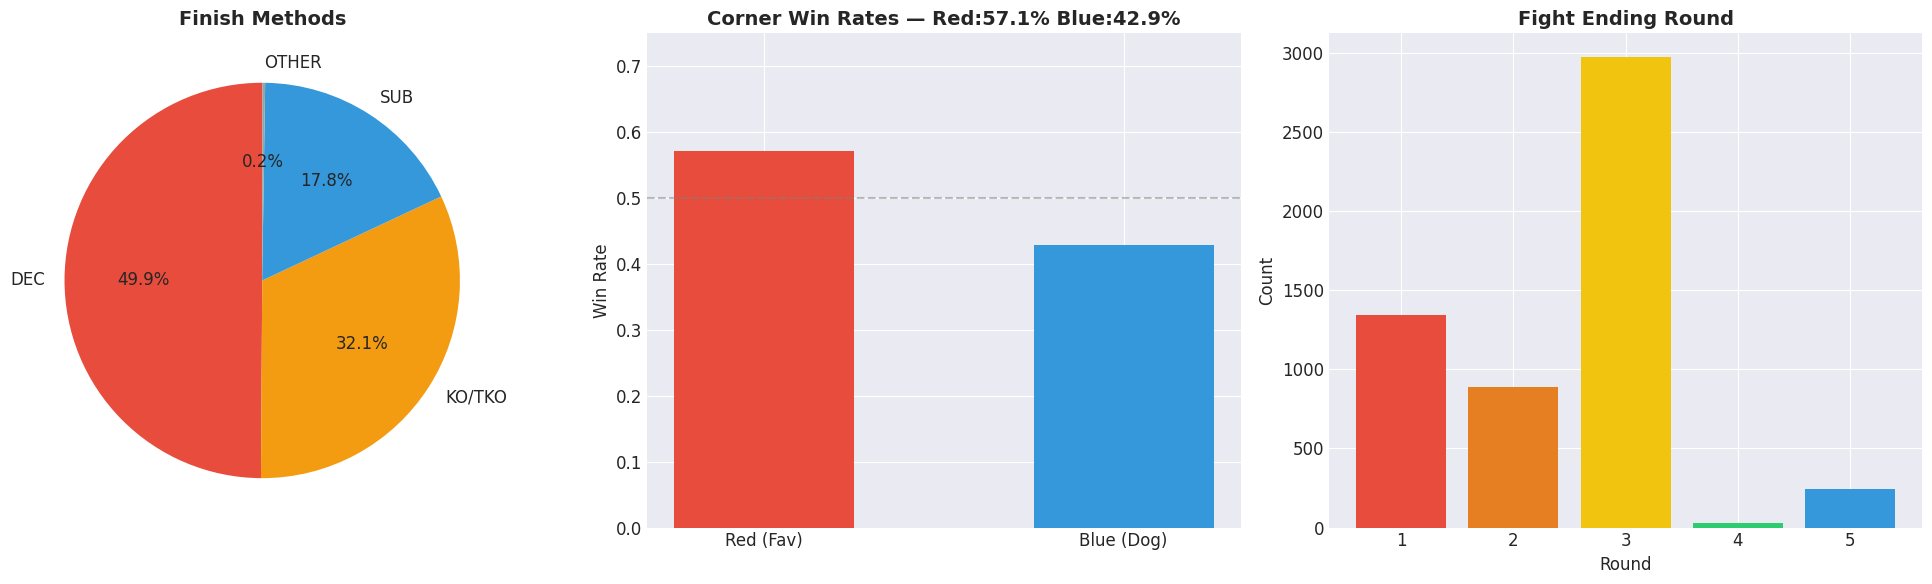

  DEC         2737 (49.9%)
  KO/TKO      1760 (32.1%)
  SUB          975 (17.8%)
  OTHER         13 (0.2%)
Avg fight length: 11.1 min


In [24]:
# notebooks/03_eda.ipynb — Cell 2: Outcome Overview

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fc = fights['finish_type'].value_counts()
axes[0].pie(fc, labels=fc.index, autopct='%1.1f%%', startangle=90,
            colors=['#e74c3c','#f39c12','#3498db','#95a5a6'][:len(fc)])
axes[0].set_title('Finish Methods')

wr = fights['f1_win'].mean()
axes[1].bar(['Red (Fav)', 'Blue (Dog)'], [wr, 1-wr],
            color=['#e74c3c','#3498db'], width=0.5)
axes[1].set_ylabel('Win Rate')
axes[1].set_title(f'Corner Win Rates — Red:{wr:.1%} Blue:{1-wr:.1%}')
axes[1].set_ylim(0, 0.75)
axes[1].axhline(y=0.5, color='gray', ls='--', alpha=0.5)

rc = fights['round'].value_counts().sort_index()
axes[2].bar(rc.index, rc.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'][:len(rc)])
axes[2].set_xlabel('Round'); axes[2].set_ylabel('Count')
axes[2].set_title('Fight Ending Round')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_01_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

for ft, cnt in fc.items():
    print(f'  {ft:10s} {cnt:>5d} ({cnt/len(fights)*100:.1f}%)')
print(f'Avg fight length: {fights["total_time_seconds"].mean()/60:.1f} min')

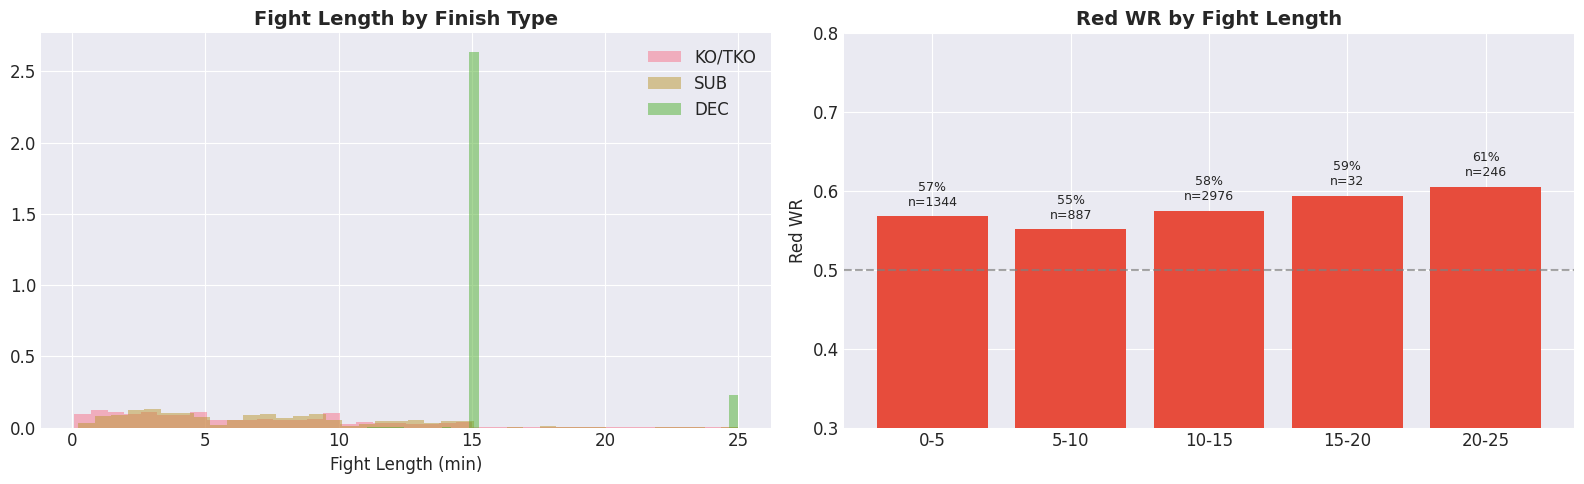

In [25]:
# notebooks/03_eda.ipynb — Cell 3: Fight Length Analysis

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ft in ['KO/TKO','SUB','DEC']:
    t = fights[fights['finish_type']==ft]['total_time_seconds']/60
    axes[0].hist(t.dropna(), bins=40, alpha=0.5, label=ft, density=True)
axes[0].set_xlabel('Fight Length (min)')
axes[0].set_title('Fight Length by Finish Type')
axes[0].legend()

fights['time_bin'] = pd.cut(fights['total_time_seconds']/60,
    bins=[0,5,10,15,20,25,30], labels=['0-5','5-10','10-15','15-20','20-25','25+'])
tw = fights.groupby('time_bin', observed=True)['f1_win'].agg(['mean','count'])
colors = ['#e74c3c' if m>0.5 else '#3498db' for m in tw['mean']]
axes[1].bar(range(len(tw)), tw['mean'], color=colors)
axes[1].set_xticks(range(len(tw))); axes[1].set_xticklabels(tw.index)
axes[1].set_ylabel('Red WR'); axes[1].set_title('Red WR by Fight Length')
axes[1].axhline(y=0.5, color='gray', ls='--', alpha=0.7)
axes[1].set_ylim(0.3, 0.8)
for i,(_, r) in enumerate(tw.iterrows()):
    axes[1].text(i, r['mean']+0.01, f'{r["mean"]:.0%}\nn={int(r["count"])}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_02_fight_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Red Corner Advantage Over Time

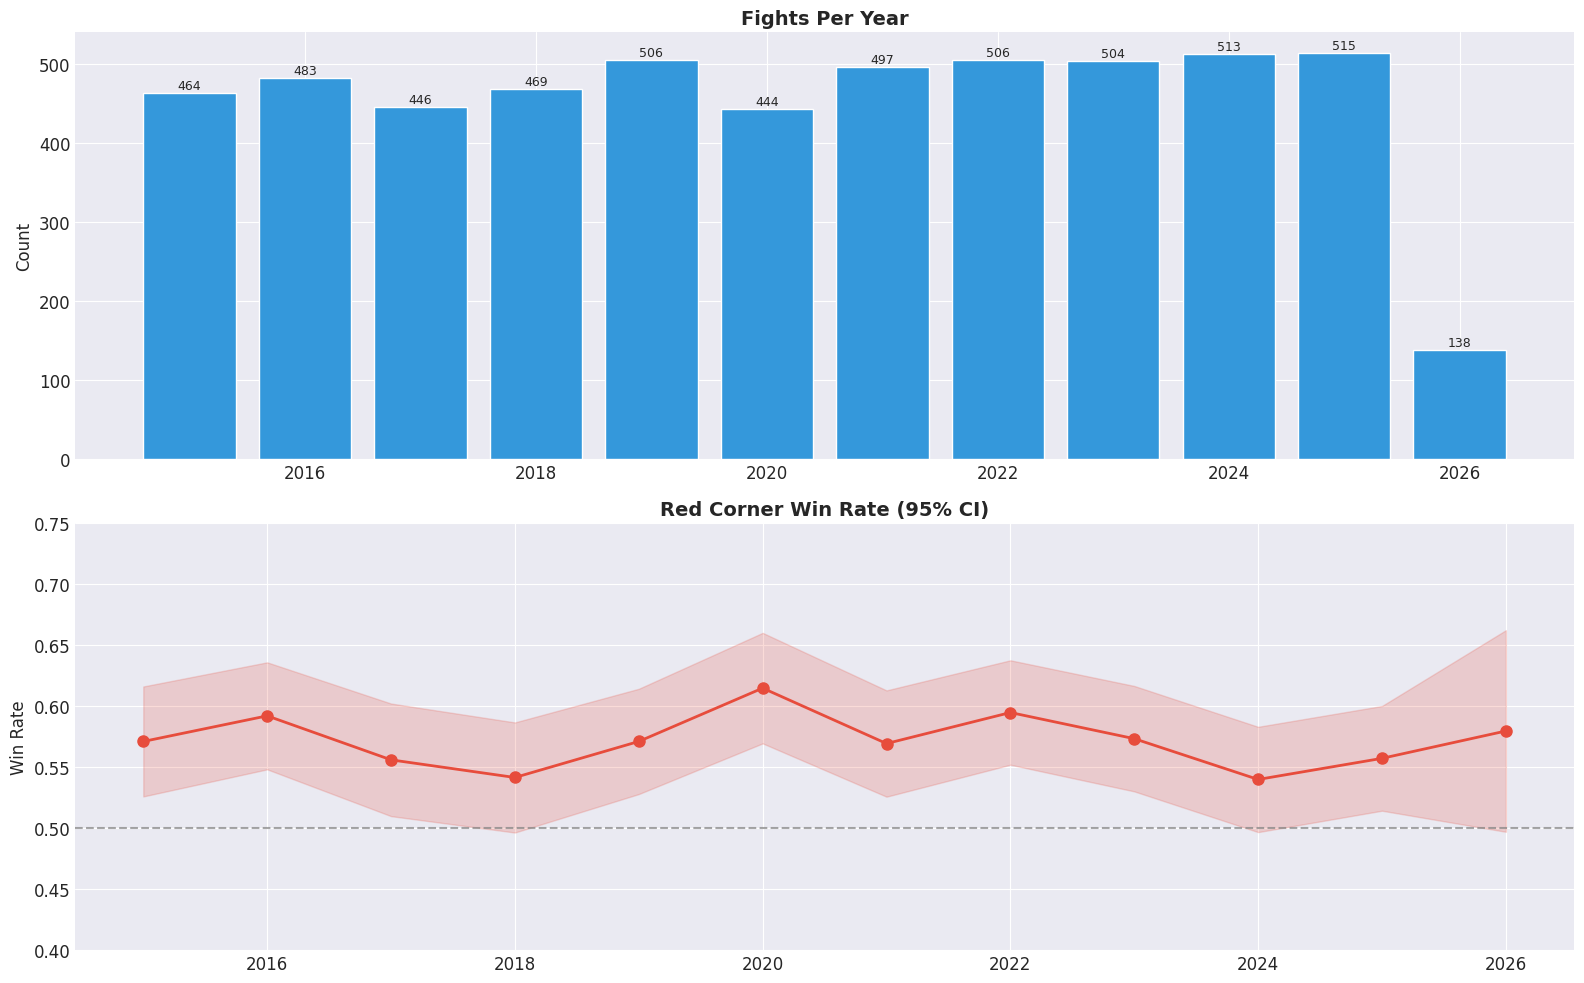

  2015: 0.571 ± 0.023 (n=464)
  2016: 0.592 ± 0.022 (n=483)
  2017: 0.556 ± 0.024 (n=446)
  2018: 0.542 ± 0.023 (n=469)
  2019: 0.571 ± 0.022 (n=506)
  2020: 0.615 ± 0.023 (n=444)
  2021: 0.569 ± 0.022 (n=497)
  2022: 0.595 ± 0.022 (n=506)
  2023: 0.573 ± 0.022 (n=504)
  2024: 0.540 ± 0.022 (n=513)
  2025: 0.557 ± 0.022 (n=515)
  2026: 0.580 ± 0.042 (n=138)


In [26]:
# notebooks/03_eda.ipynb — Cell 4: Red WR Over Time

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

yearly = fights.groupby('year').size()
axes[0].bar(yearly.index, yearly.values, color='#3498db', edgecolor='white')
axes[0].set_title('Fights Per Year'); axes[0].set_ylabel('Count')
for x,y in zip(yearly.index, yearly.values):
    axes[0].text(x, y+5, str(y), ha='center', fontsize=9)

ys = fights.groupby('year')['f1_win'].agg(['mean','count','std'])
ys['se'] = ys['std']/np.sqrt(ys['count'])
ys['lo'] = ys['mean'] - 1.96*ys['se']
ys['hi'] = ys['mean'] + 1.96*ys['se']
axes[1].plot(ys.index, ys['mean'], 'o-', color='#e74c3c', lw=2, ms=8)
axes[1].fill_between(ys.index, ys['lo'], ys['hi'], alpha=0.2, color='#e74c3c')
axes[1].axhline(y=0.5, color='gray', ls='--', alpha=0.7)
axes[1].set_title('Red Corner Win Rate (95% CI)')
axes[1].set_ylabel('Win Rate'); axes[1].set_ylim(0.40, 0.75)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_03_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

for yr, r in ys.iterrows():
    print(f'  {int(yr)}: {r["mean"]:.3f} ± {r["se"]:.3f} (n={int(r["count"])})')

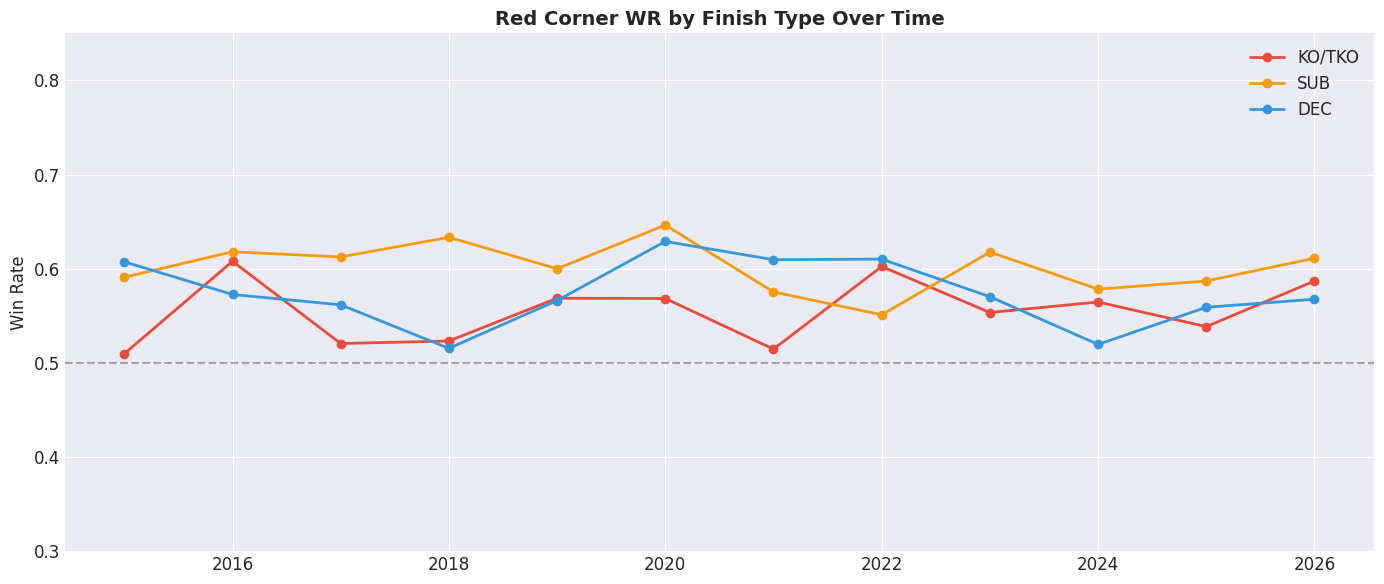

In [27]:
# notebooks/03_eda.ipynb — Cell 5: Red WR by Finish Type Over Time

fig, ax = plt.subplots(figsize=(14, 6))
cmap = {'KO/TKO':'#e74c3c', 'SUB':'#f39c12', 'DEC':'#3498db'}
for ft in ['KO/TKO','SUB','DEC']:
    s = fights[fights['finish_type']==ft].groupby('year')['f1_win'].mean()
    ax.plot(s.index, s.values, 'o-', label=ft, color=cmap[ft], lw=2, ms=6)
ax.axhline(y=0.5, color='gray', ls='--', alpha=0.7)
ax.set_title('Red Corner WR by Finish Type Over Time')
ax.set_ylabel('Win Rate'); ax.set_ylim(0.30, 0.85); ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_04_wr_by_finish.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Weight Classes

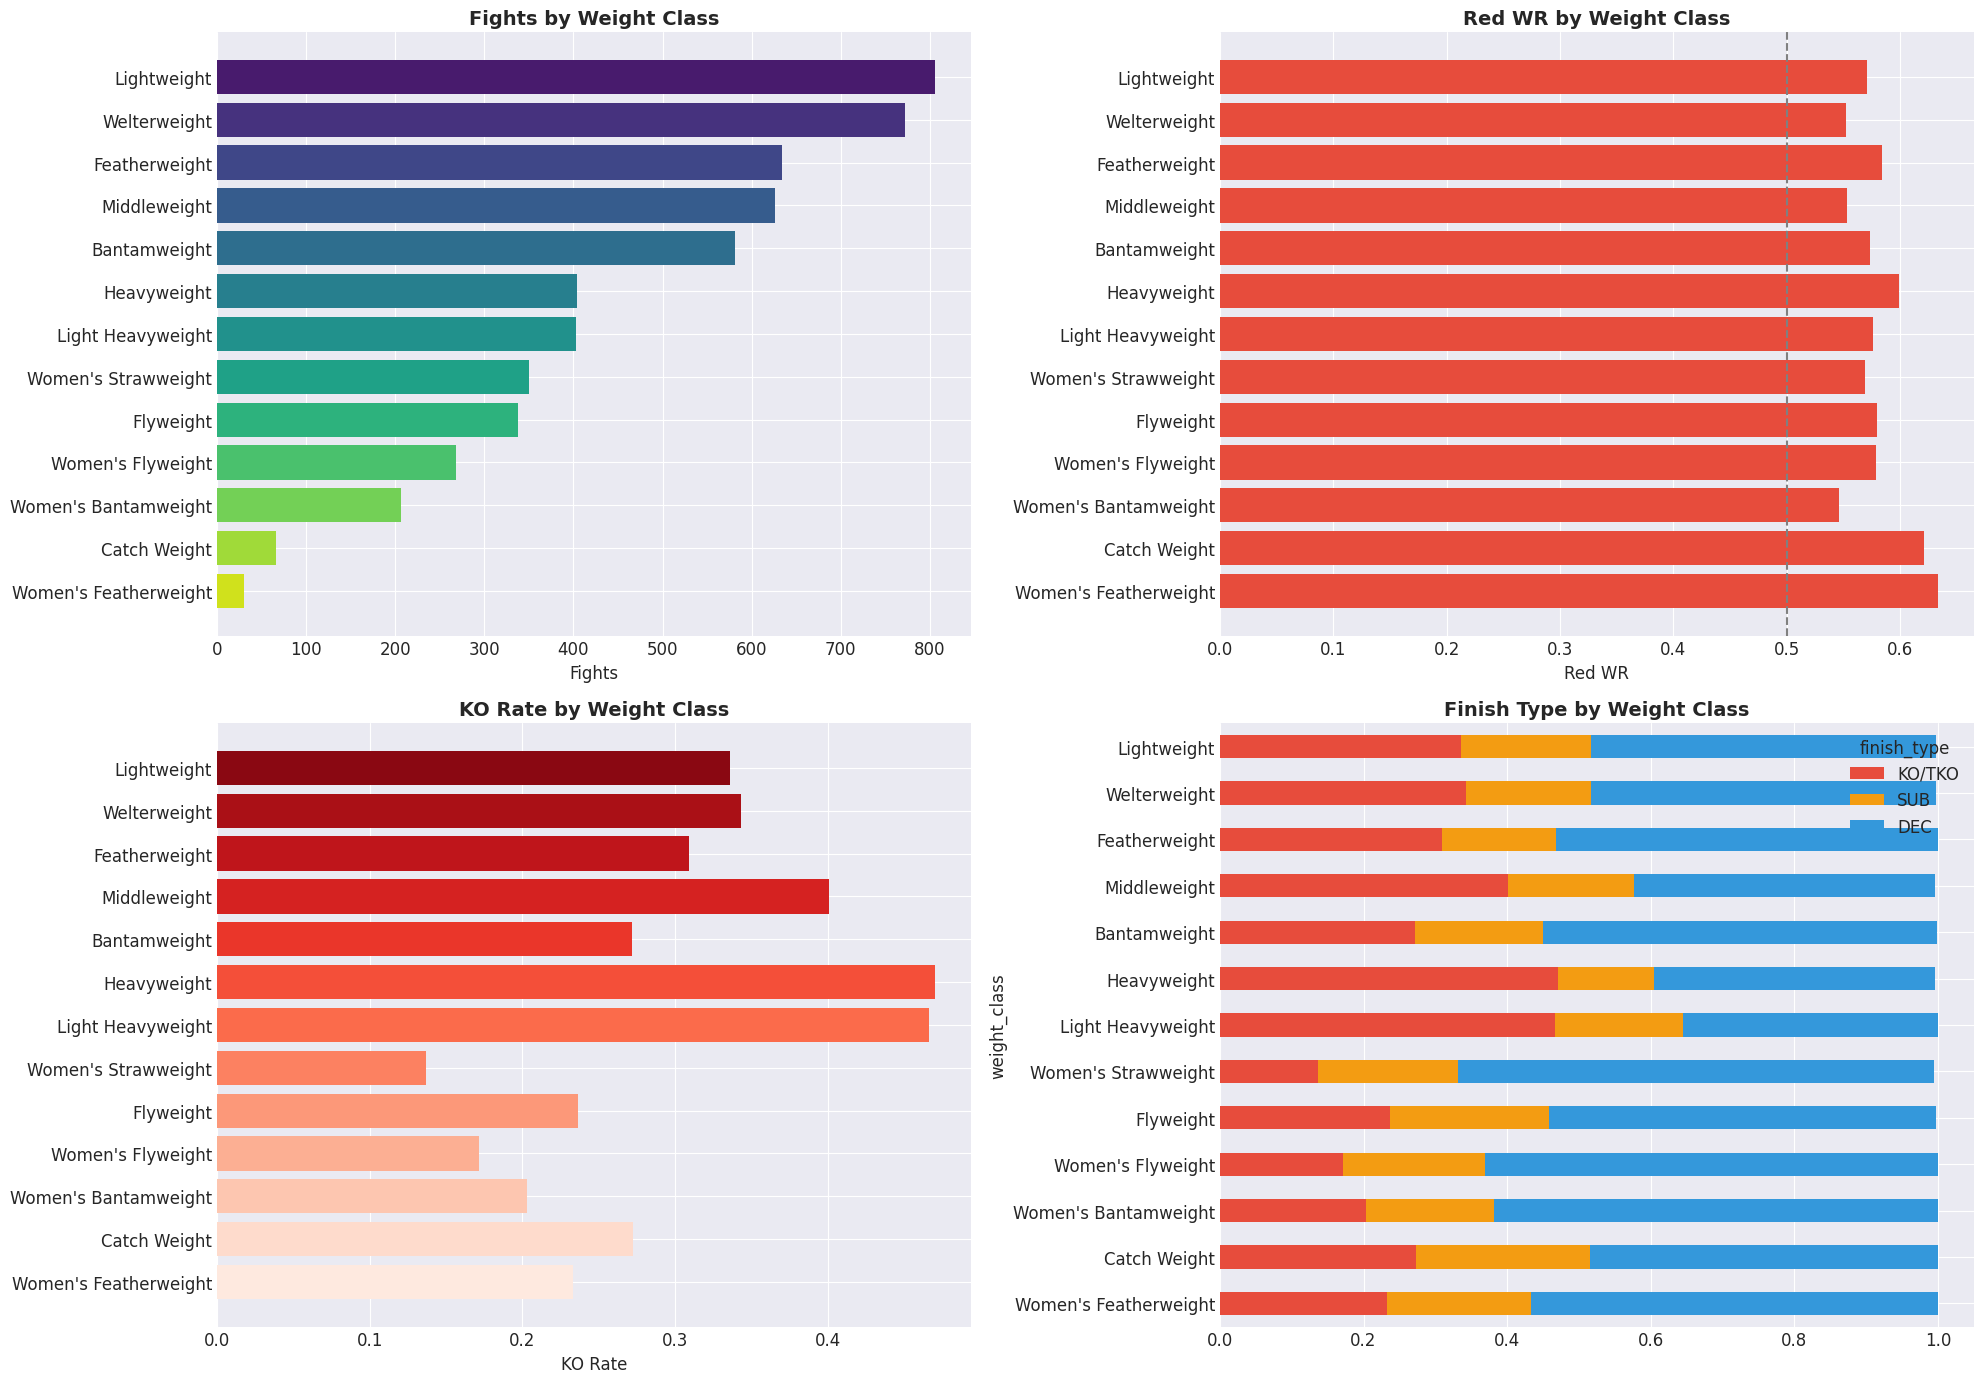

  Lightweight                              n= 806  RedWR=57%  KO=34%
  Welterweight                             n= 772  RedWR=55%  KO=34%
  Featherweight                            n= 634  RedWR=58%  KO=31%
  Middleweight                             n= 626  RedWR=55%  KO=40%
  Bantamweight                             n= 581  RedWR=57%  KO=27%
  Heavyweight                              n= 404  RedWR=60%  KO=47%
  Light Heavyweight                        n= 403  RedWR=58%  KO=47%
  Women's Strawweight                      n= 350  RedWR=57%  KO=14%
  Flyweight                                n= 338  RedWR=58%  KO=24%
  Women's Flyweight                        n= 268  RedWR=58%  KO=17%
  Women's Bantamweight                     n= 207  RedWR=55%  KO=20%
  Catch Weight                             n=  66  RedWR=62%  KO=27%
  Women's Featherweight                    n=  30  RedWR=63%  KO=23%


In [28]:
# notebooks/03_eda.ipynb — Cell 6: Weight Class Deep Dive

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
wcc = fights['weight_class'].value_counts()
top = wcc.index.tolist()

axes[0,0].barh(range(len(wcc)), wcc.values,
    color=sns.color_palette('viridis', len(wcc)))
axes[0,0].set_yticks(range(len(wcc))); axes[0,0].set_yticklabels(wcc.index)
axes[0,0].set_xlabel('Fights'); axes[0,0].set_title('Fights by Weight Class')
axes[0,0].invert_yaxis()

wwr = fights.groupby('weight_class')['f1_win'].mean().reindex(top)
axes[0,1].barh(range(len(wwr)), wwr.values,
    color=['#e74c3c' if v>0.5 else '#3498db' for v in wwr.values])
axes[0,1].set_yticks(range(len(wwr))); axes[0,1].set_yticklabels(wwr.index)
axes[0,1].set_xlabel('Red WR'); axes[0,1].set_title('Red WR by Weight Class')
axes[0,1].axvline(x=0.5, color='gray', ls='--'); axes[0,1].invert_yaxis()

wko = fights.groupby('weight_class').apply(
    lambda x: (x['finish_type']=='KO/TKO').mean()).reindex(top)
axes[1,0].barh(range(len(wko)), wko.values,
    color=sns.color_palette('Reds_r', len(wko)))
axes[1,0].set_yticks(range(len(wko))); axes[1,0].set_yticklabels(wko.index)
axes[1,0].set_xlabel('KO Rate'); axes[1,0].set_title('KO Rate by Weight Class')
axes[1,0].invert_yaxis()

ft_wc = fights.groupby(['weight_class','finish_type']).size().unstack(fill_value=0).reindex(top)
ft_pct = ft_wc.div(ft_wc.sum(axis=1), axis=0)
cols = [c for c in ['KO/TKO','SUB','DEC'] if c in ft_pct.columns]
ft_pct[cols].plot(kind='barh', stacked=True, ax=axes[1,1],
    color=['#e74c3c','#f39c12','#3498db'][:len(cols)])
axes[1,1].set_title('Finish Type by Weight Class'); axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_05_weight_classes.png', dpi=150, bbox_inches='tight')
plt.show()

for wc in top:
    s = fights[fights['weight_class']==wc]
    print(f'  {wc:40s} n={len(s):>4d}  RedWR={s["f1_win"].mean():.0%}  '
          f'KO={(s["finish_type"]=="KO/TKO").mean():.0%}')

## 4. Winner vs Loser Stats

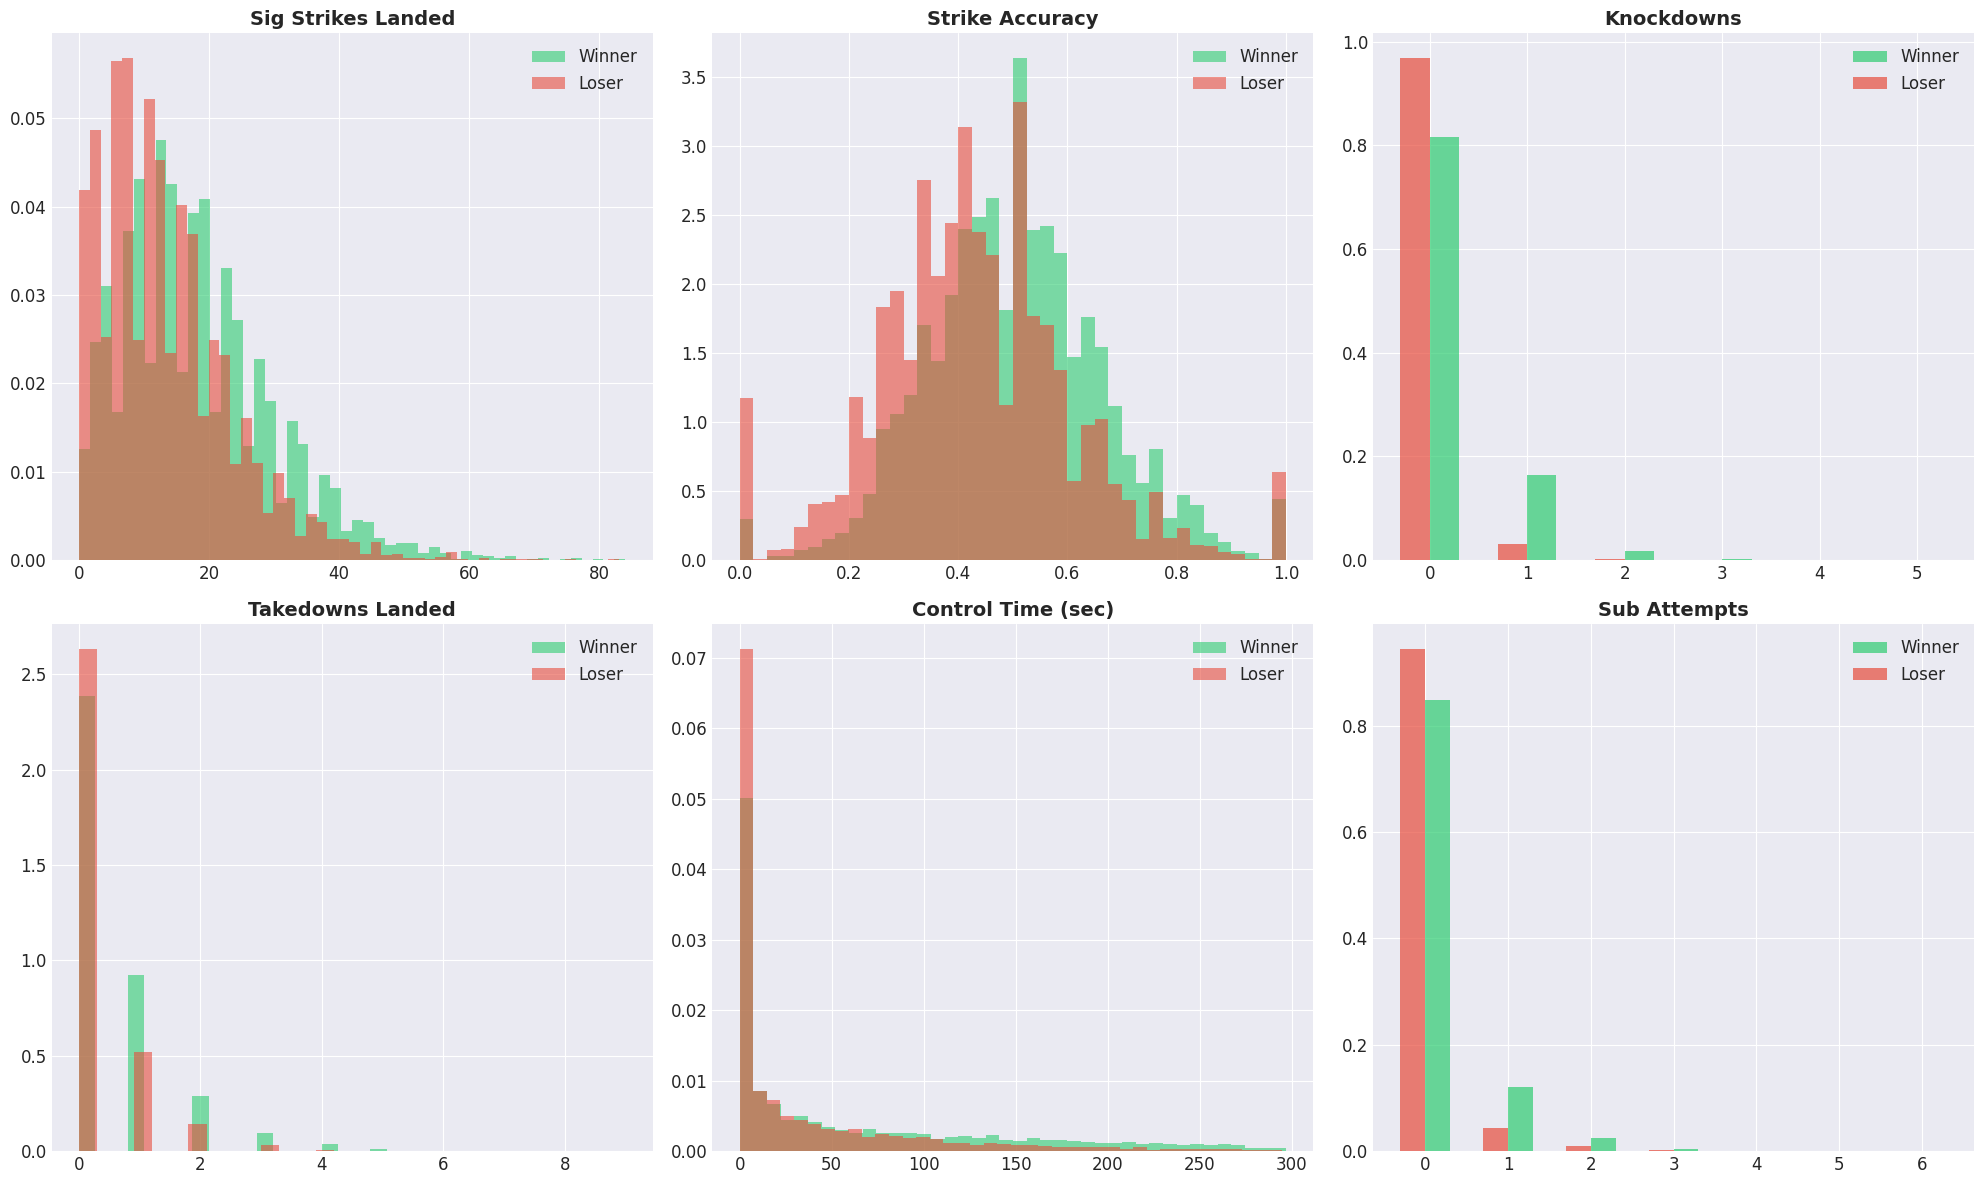

Winner vs Loser means:
  str_landed           W=   18.29  L=   13.24  diff=+5.05
  str_attempted        W=   37.60  L=   31.57  diff=+6.03
  str_acc              W=    0.50  L=    0.43  diff=+0.08
  td_landed            W=    0.54  L=    0.28  diff=+0.26
  td_attempted         W=    1.18  L=    0.96  diff=+0.23
  td_acc               W=    0.26  L=    0.14  diff=+0.12
  kd                   W=    0.21  L=    0.03  diff=+0.17
  sub                  W=    0.19  L=    0.07  diff=+0.12
  rev                  W=    0.05  L=    0.05  diff=+0.00
  ctrl_seconds         W=   62.24  L=   34.55  diff=+27.69
  head_landed          W=   11.27  L=    7.16  diff=+4.11
  body_landed          W=    3.76  L=    3.10  diff=+0.65
  leg_landed           W=    3.27  L=    2.98  diff=+0.29
  distance_landed      W=   13.19  L=   10.84  diff=+2.35
  clinch_landed        W=    2.25  L=    1.65  diff=+0.60
  ground_landed        W=    2.86  L=    0.75  diff=+2.10


In [29]:
# notebooks/03_eda.ipynb — Cell 7: Winner vs Loser Stats

stat_list = ['str_landed','str_attempted','str_acc','td_landed','td_attempted',
             'td_acc','kd','sub','rev','ctrl_seconds',
             'head_landed','body_landed','leg_landed',
             'distance_landed','clinch_landed','ground_landed']
for stat in stat_list:
    c1, c2 = f'f1_{stat}', f'f2_{stat}'
    if c1 in fights.columns and c2 in fights.columns:
        fights[f'winner_{stat}'] = np.where(fights['f1_win']==1, fights[c1], fights[c2])
        fights[f'loser_{stat}'] = np.where(fights['f1_win']==1, fights[c2], fights[c1])

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
pairs = [
    (axes[0,0], 'str_landed', 'Sig Strikes Landed', 50),
    (axes[0,1], 'str_acc', 'Strike Accuracy', 40),
    (axes[0,2], 'kd', 'Knockdowns', None),
    (axes[1,0], 'td_landed', 'Takedowns Landed', 30),
    (axes[1,1], 'ctrl_seconds', 'Control Time (sec)', 40),
    (axes[1,2], 'sub', 'Sub Attempts', None),
]
for ax, stat, title, nbins in pairs:
    w = fights[f'winner_{stat}'].dropna()
    l = fights[f'loser_{stat}'].dropna()
    if nbins:
        ax.hist(w, bins=nbins, alpha=0.6, label='Winner', color='#2ecc71', density=True)
        ax.hist(l, bins=nbins, alpha=0.6, label='Loser', color='#e74c3c', density=True)
    else:
        for lbl, vals, clr in [('Winner',w,'#2ecc71'),('Loser',l,'#e74c3c')]:
            vc = vals.value_counts().sort_index().head(8)
            off = 0.15 if lbl=='Winner' else -0.15
            ax.bar(vc.index+off, vc.values/len(vals), width=0.3, alpha=0.7,
                   label=lbl, color=clr)
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_06_winner_vs_loser.png', dpi=150, bbox_inches='tight')
plt.show()

print('Winner vs Loser means:')
for s in stat_list:
    if f'winner_{s}' in fights.columns:
        wm = fights[f'winner_{s}'].mean()
        lm = fights[f'loser_{s}'].mean()
        print(f'  {s:20s} W={wm:8.2f}  L={lm:8.2f}  diff={wm-lm:+.2f}')

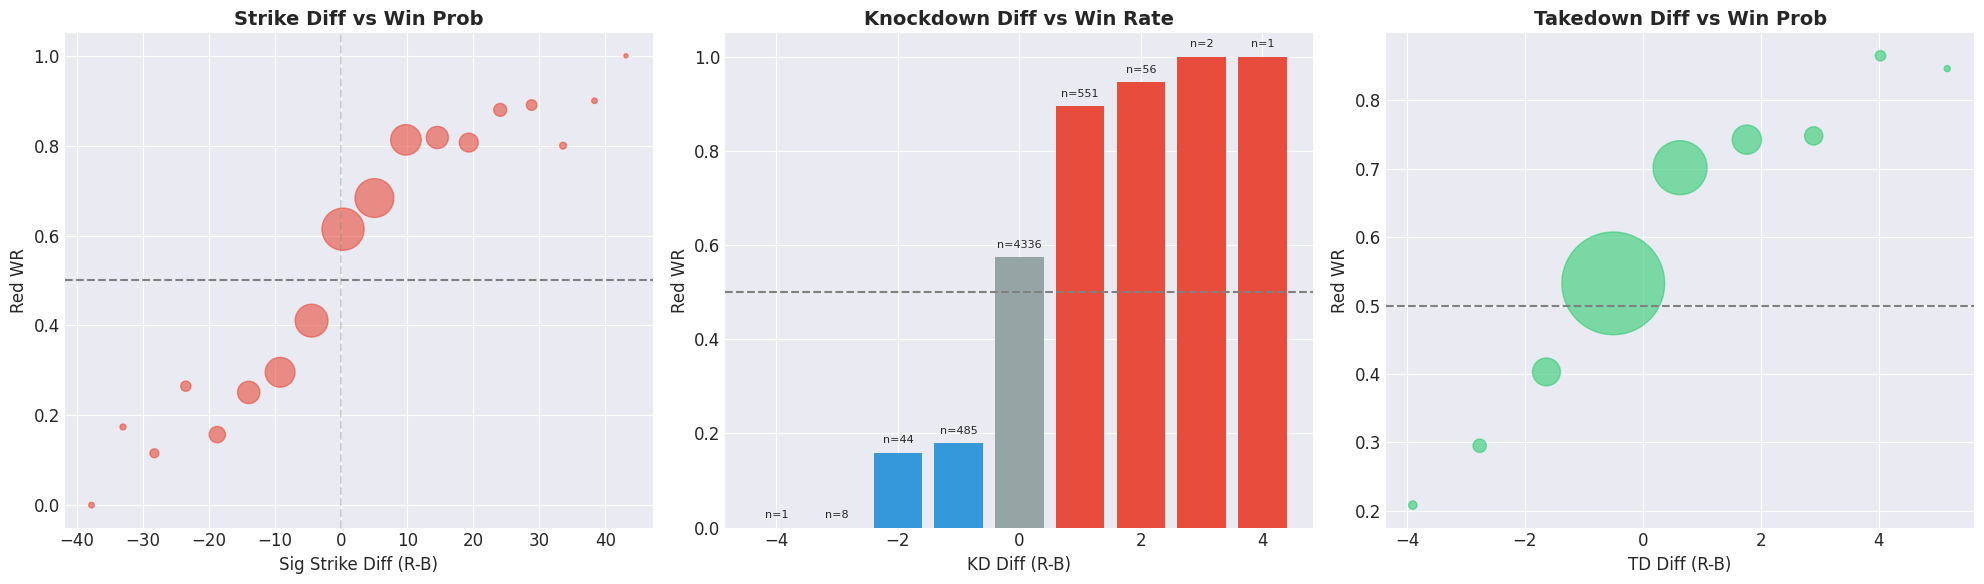

In [30]:
# notebooks/03_eda.ipynb — Cell 8: Stat Differentials vs Win Probability

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fights['str_diff'] = fights['f1_str_landed'] - fights['f2_str_landed']
sb = pd.cut(fights['str_diff'], bins=25)
sw = fights.groupby(sb, observed=True)['f1_win'].agg(['mean','count'])
sw = sw[sw['count']>=10]
xv = [i.mid for i in sw.index]
axes[0].scatter(xv, sw['mean'], s=sw['count']*0.8, alpha=0.6, c='#e74c3c')
axes[0].axhline(y=0.5, color='gray', ls='--'); axes[0].axvline(x=0, color='gray', ls='--', alpha=0.3)
axes[0].set_xlabel('Sig Strike Diff (R-B)'); axes[0].set_ylabel('Red WR')
axes[0].set_title('Strike Diff vs Win Prob')

fights['kd_diff'] = fights['f1_kd'] - fights['f2_kd']
kw = fights.groupby('kd_diff')['f1_win'].agg(['mean','count'])
kw = kw[(kw.index>=-4)&(kw.index<=4)]
kc = ['#3498db' if i<0 else '#e74c3c' if i>0 else '#95a5a6' for i in kw.index]
axes[1].bar(kw.index, kw['mean'], color=kc)
axes[1].axhline(y=0.5, color='gray', ls='--')
axes[1].set_xlabel('KD Diff (R-B)'); axes[1].set_ylabel('Red WR')
axes[1].set_title('Knockdown Diff vs Win Rate')
for k, r in kw.iterrows():
    axes[1].text(k, r['mean']+0.02, f'n={int(r["count"])}', ha='center', fontsize=8)

fights['td_diff'] = fights['f1_td_landed'] - fights['f2_td_landed']
tb = pd.cut(fights['td_diff'], bins=15)
tw2 = fights.groupby(tb, observed=True)['f1_win'].agg(['mean','count'])
tw2 = tw2[tw2['count']>=10]
xt = [i.mid for i in tw2.index]
axes[2].scatter(xt, tw2['mean'], s=tw2['count']*1.5, alpha=0.6, c='#2ecc71')
axes[2].axhline(y=0.5, color='gray', ls='--')
axes[2].set_xlabel('TD Diff (R-B)'); axes[2].set_ylabel('Red WR')
axes[2].set_title('Takedown Diff vs Win Prob')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_07_differentials.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Strike Location & Position Breakdown (NEW)

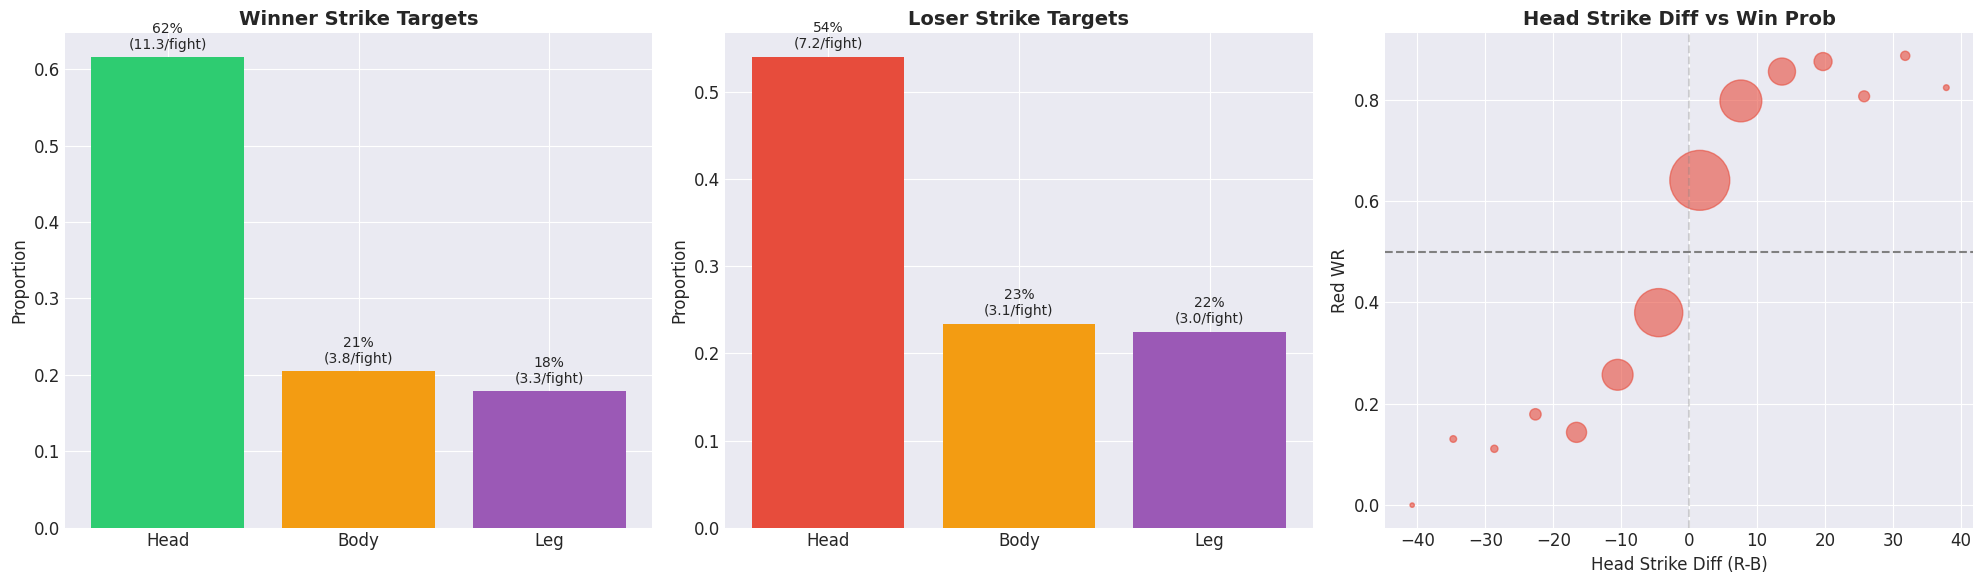

Strike location means (per fight):
  head    W=11.27  L=7.16  diff=+4.11
  body    W=3.76  L=3.10  diff=+0.65
  leg     W=3.27  L=2.98  diff=+0.29


In [31]:
# notebooks/03_eda.ipynb — Cell 9: Strike Location (head/body/leg)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Overall distribution of where strikes land
for p, ax, title, color in [
    ('winner', axes[0], 'Winner Strike Targets', '#2ecc71'),
    ('loser', axes[1], 'Loser Strike Targets', '#e74c3c'),
]:
    head = fights[f'{p}_head_landed'].mean()
    body = fights[f'{p}_body_landed'].mean()
    leg = fights[f'{p}_leg_landed'].mean()
    total = head + body + leg
    vals = [head/total, body/total, leg/total]
    ax.bar(['Head','Body','Leg'], vals, color=[color,'#f39c12','#9b59b6'])
    ax.set_title(title); ax.set_ylabel('Proportion')
    for i, v in enumerate(vals):
        ax.text(i, v+0.01, f'{v:.0%}\n({[head,body,leg][i]:.1f}/fight)',
                ha='center', fontsize=10)

# Head strike diff vs win rate
fights['head_diff'] = fights['f1_head_landed'] - fights['f2_head_landed']
hb = pd.cut(fights['head_diff'], bins=20)
hw = fights.groupby(hb, observed=True)['f1_win'].agg(['mean','count'])
hw = hw[hw['count']>=10]
xh = [i.mid for i in hw.index]
axes[2].scatter(xh, hw['mean'], s=hw['count'], alpha=0.6, c='#e74c3c')
axes[2].axhline(y=0.5, color='gray', ls='--')
axes[2].axvline(x=0, color='gray', ls='--', alpha=0.3)
axes[2].set_xlabel('Head Strike Diff (R-B)')
axes[2].set_ylabel('Red WR')
axes[2].set_title('Head Strike Diff vs Win Prob')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_08_strike_location.png', dpi=150, bbox_inches='tight')
plt.show()

print('Strike location means (per fight):')
for loc in ['head','body','leg']:
    wm = fights[f'winner_{loc}_landed'].mean()
    lm = fights[f'loser_{loc}_landed'].mean()
    print(f'  {loc:6s}  W={wm:.2f}  L={lm:.2f}  diff={wm-lm:+.2f}')

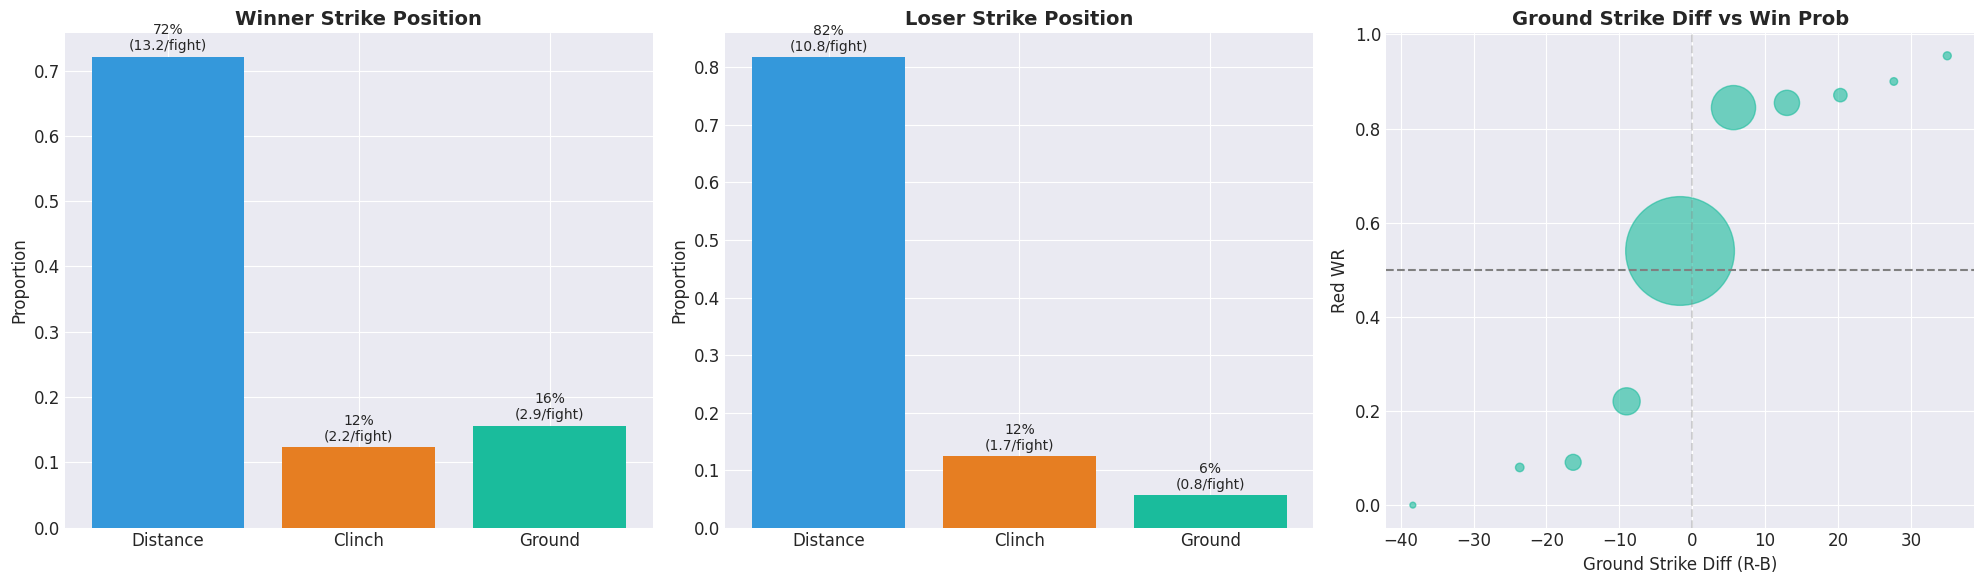

Strike position means (per fight):
  distance    W=13.19  L=10.84  diff=+2.35
  clinch      W=2.25  L=1.65  diff=+0.60
  ground      W=2.86  L=0.75  diff=+2.10


In [32]:
# notebooks/03_eda.ipynb — Cell 10: Strike Position (distance/clinch/ground)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for p, ax, title, color in [
    ('winner', axes[0], 'Winner Strike Position', '#2ecc71'),
    ('loser', axes[1], 'Loser Strike Position', '#e74c3c'),
]:
    dist = fights[f'{p}_distance_landed'].mean()
    clin = fights[f'{p}_clinch_landed'].mean()
    gnd = fights[f'{p}_ground_landed'].mean()
    total = dist + clin + gnd
    vals = [dist/total, clin/total, gnd/total]
    ax.bar(['Distance','Clinch','Ground'], vals,
           color=['#3498db','#e67e22','#1abc9c'])
    ax.set_title(title); ax.set_ylabel('Proportion')
    for i, v in enumerate(vals):
        ax.text(i, v+0.01, f'{v:.0%}\n({[dist,clin,gnd][i]:.1f}/fight)',
                ha='center', fontsize=10)

# Ground strike diff vs win rate
fights['ground_diff'] = fights['f1_ground_landed'] - fights['f2_ground_landed']
gb = pd.cut(fights['ground_diff'], bins=15)
gw = fights.groupby(gb, observed=True)['f1_win'].agg(['mean','count'])
gw = gw[gw['count']>=10]
xg = [i.mid for i in gw.index]
axes[2].scatter(xg, gw['mean'], s=gw['count']*1.5, alpha=0.6, c='#1abc9c')
axes[2].axhline(y=0.5, color='gray', ls='--')
axes[2].axvline(x=0, color='gray', ls='--', alpha=0.3)
axes[2].set_xlabel('Ground Strike Diff (R-B)')
axes[2].set_ylabel('Red WR')
axes[2].set_title('Ground Strike Diff vs Win Prob')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_09_strike_position.png', dpi=150, bbox_inches='tight')
plt.show()

print('Strike position means (per fight):')
for pos in ['distance','clinch','ground']:
    wm = fights[f'winner_{pos}_landed'].mean()
    lm = fights[f'loser_{pos}_landed'].mean()
    print(f'  {pos:10s}  W={wm:.2f}  L={lm:.2f}  diff={wm-lm:+.2f}')

## 6. Fighter Career Rate Stats (NEW)

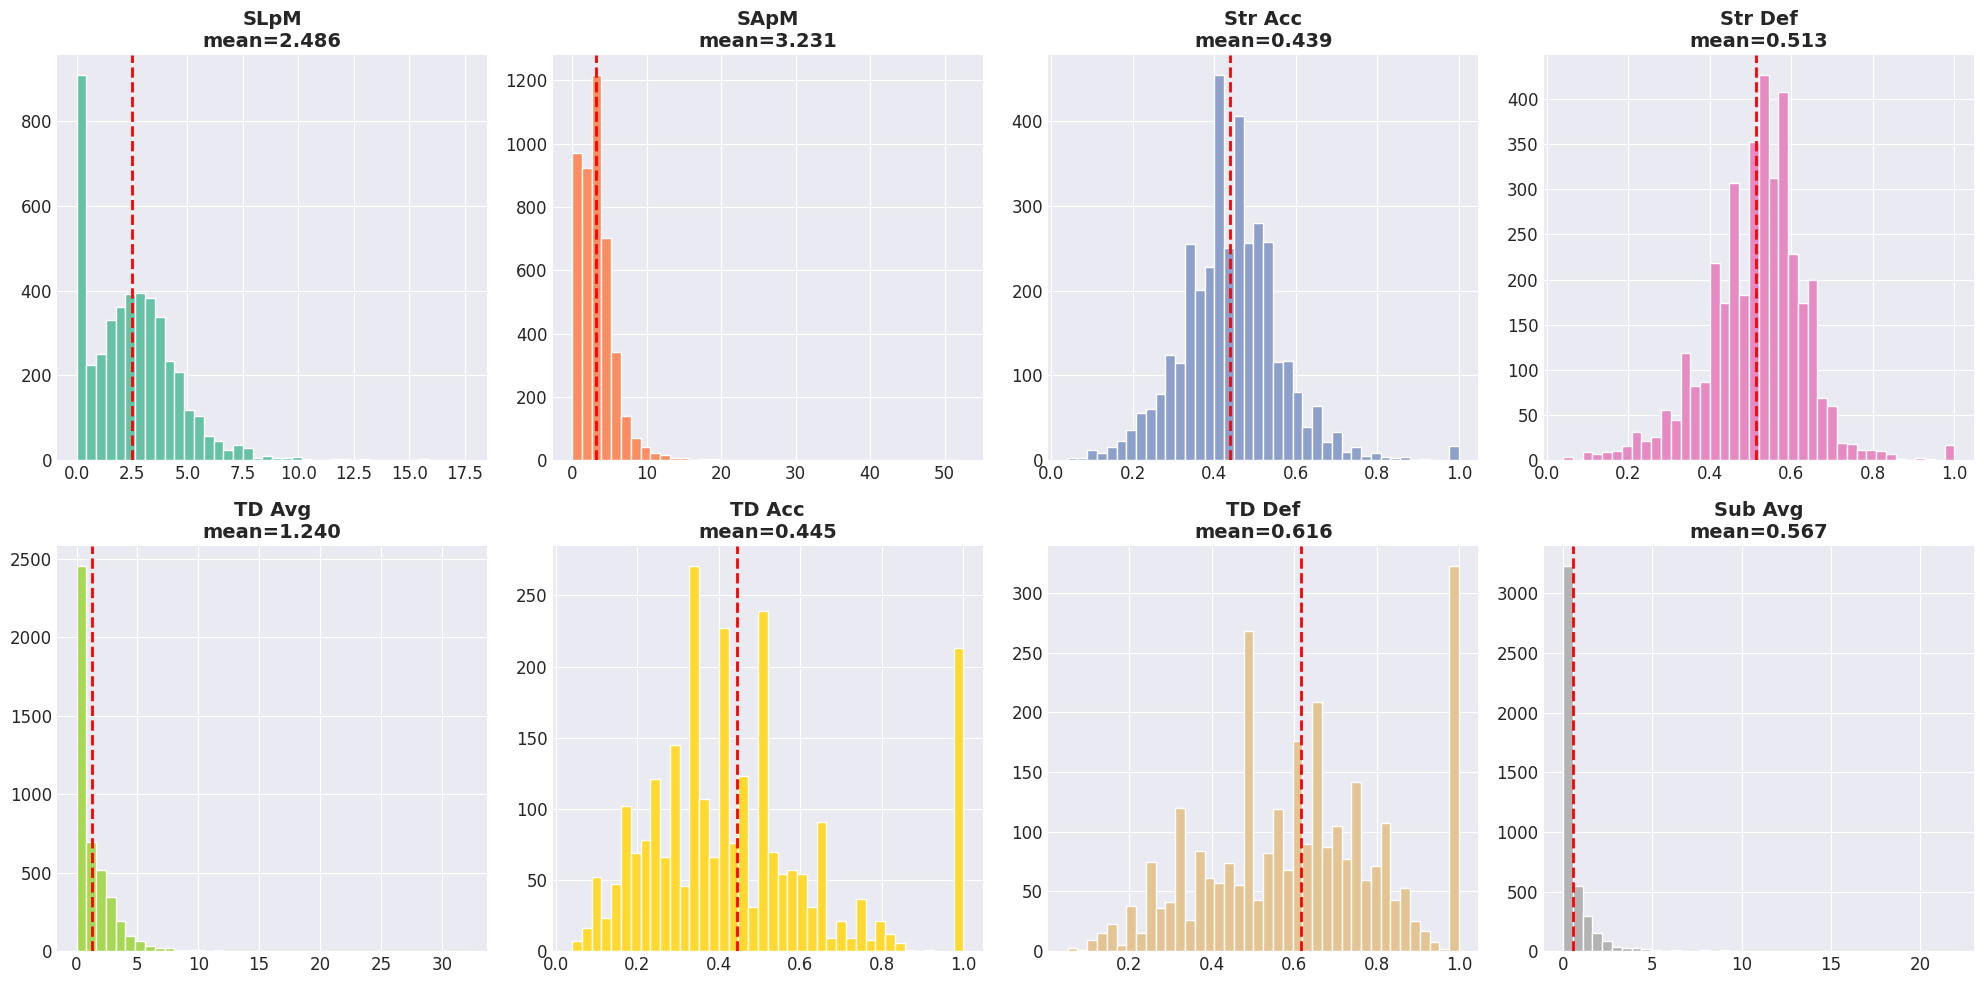

Fighter career stat summary:
  SLpM       n= 4486  mean=2.486  std=1.987  min=0.000  max=17.650
  SApM       n= 4486  mean=3.231  std=2.950  min=0.000  max=52.500
  Str Acc    n= 3659  mean=0.439  std=0.121  min=0.040  max=1.000
  Str Def    n= 3727  mean=0.513  std=0.119  min=0.040  max=1.000
  TD Avg     n= 4486  mean=1.240  std=1.895  min=0.000  max=32.140
  TD Acc     n= 2607  mean=0.445  std=0.228  min=0.040  max=1.000
  TD Def     n= 2913  mean=0.616  std=0.221  min=0.050  max=1.000
  Sub Avg    n= 4486  mean=0.567  std=1.426  min=0.000  max=21.900


In [33]:
# notebooks/03_eda.ipynb — Cell 11: Fighter Career Rate Stats

rate_cols = ['slpm','sapm','str_acc_career','str_def_career',
             'td_avg','td_acc_career','td_def_career','sub_avg']
labels = ['SLpM','SApM','Str Acc','Str Def',
          'TD Avg','TD Acc','TD Def','Sub Avg']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors = sns.color_palette('Set2', 8)
for i, (col, label) in enumerate(zip(rate_cols, labels)):
    data = fighters[col].dropna()
    if len(data) > 0:
        axes[i].hist(data, bins=40, color=colors[i], edgecolor='white')
        axes[i].axvline(x=data.mean(), color='red', ls='--', lw=2)
        axes[i].set_title(f'{label}\nmean={data.mean():.3f}')
    else:
        axes[i].set_title(f'{label} (no data)')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_10_career_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print('Fighter career stat summary:')
for col, label in zip(rate_cols, labels):
    d = fighters[col].dropna()
    print(f'  {label:10s} n={len(d):>5d}  '
          f'mean={d.mean():.3f}  std={d.std():.3f}  '
          f'min={d.min():.3f}  max={d.max():.3f}')

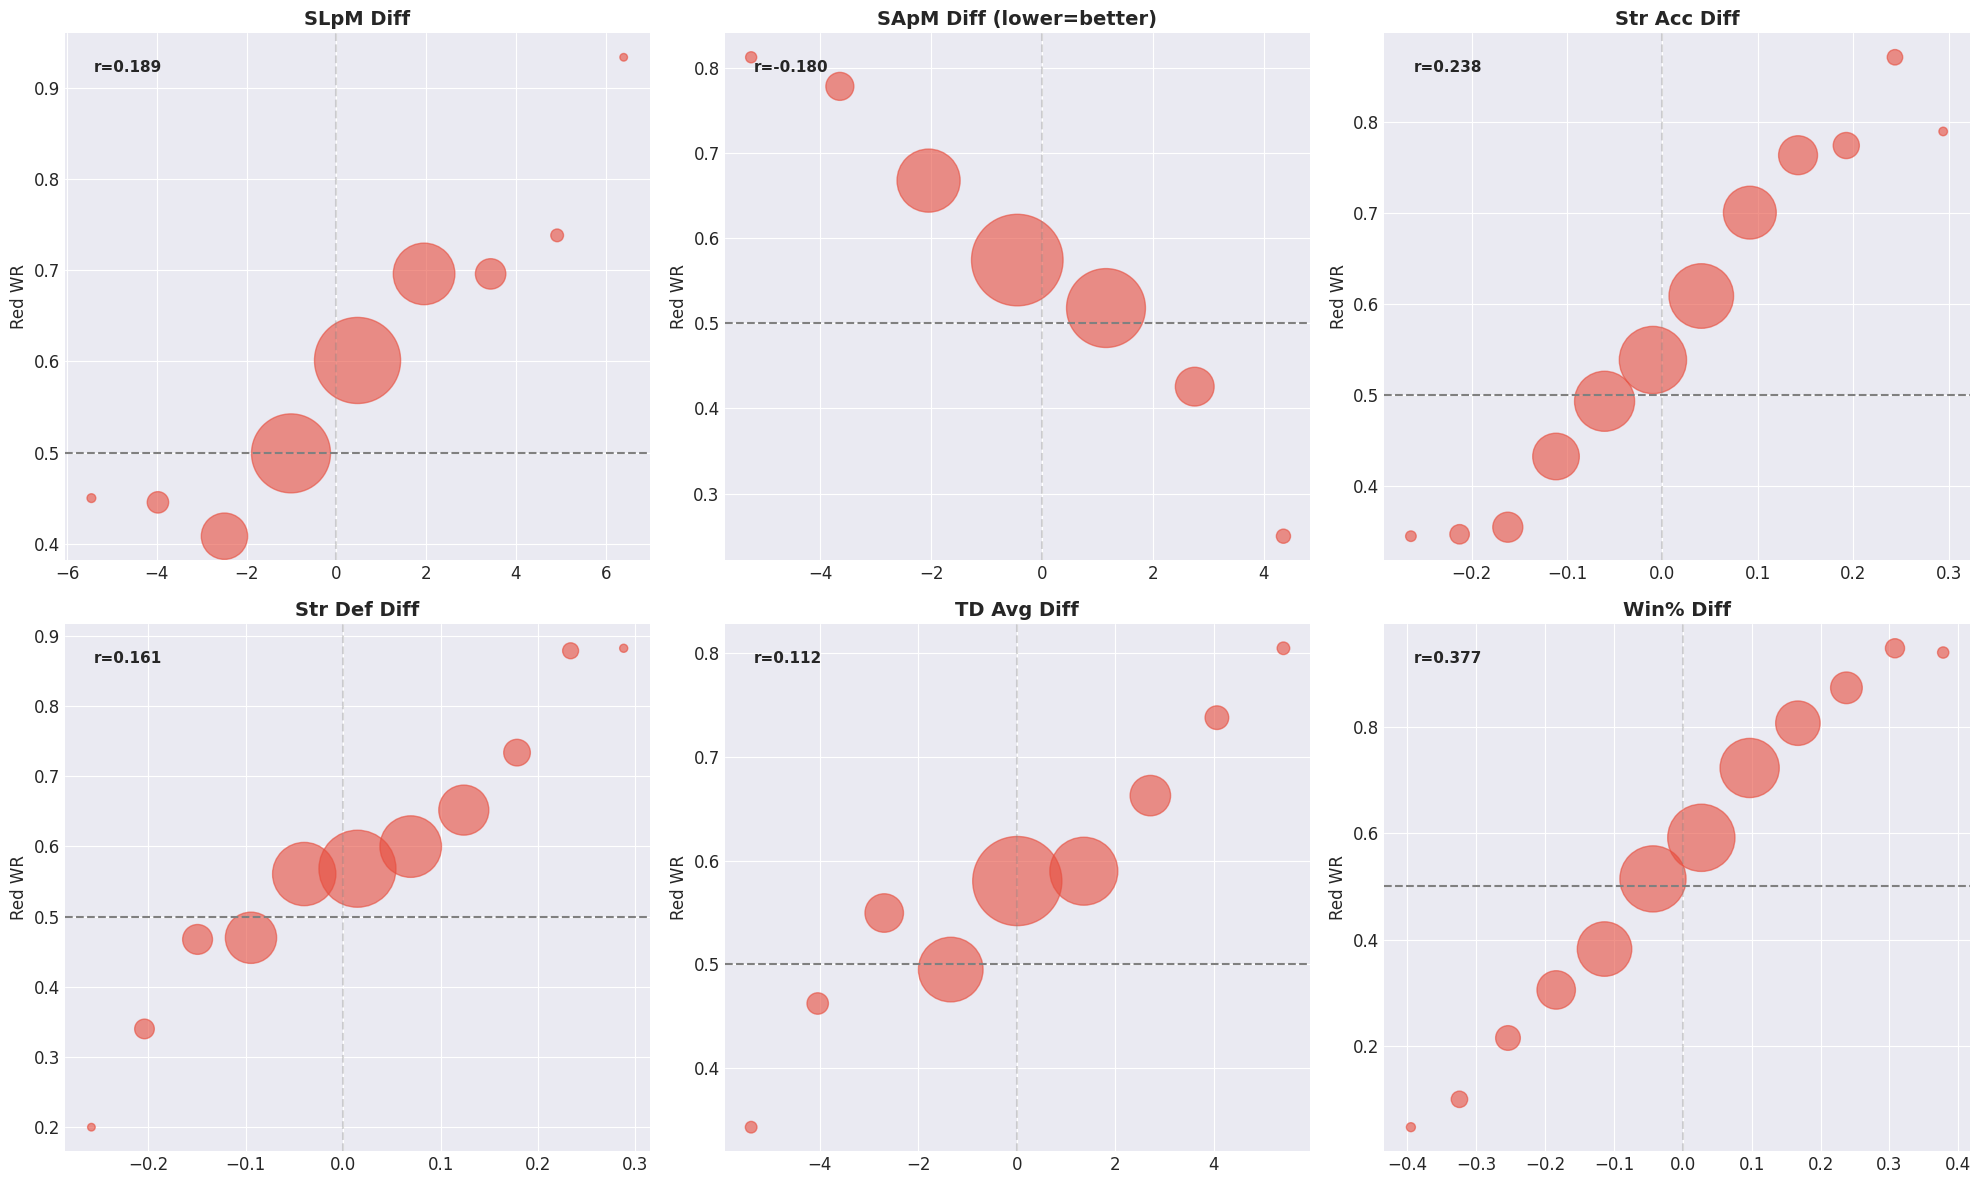

Career stat diff correlations with f1_win:
  SLpM Diff                      r=+0.1894  (n=5524)
  SApM Diff (lower=better)       r=-0.1795  (n=5524)
  Str Acc Diff                   r=+0.2381  (n=5511)
  Str Def Diff                   r=+0.1614  (n=5517)
  TD Avg Diff                    r=+0.1121  (n=5524)
  Win% Diff                      r=+0.3768  (n=5524)


In [34]:
# notebooks/03_eda.ipynb — Cell 12: Career Stat Diffs vs Win Rate

fp = fighters[['full_name','slpm','sapm','str_acc_career','str_def_career',
               'td_avg','td_acc_career','td_def_career','sub_avg','win_pct']].copy()

# Merge fighter career stats into fights
fm = fights.merge(
    fp.rename(columns=lambda c: f'f1_{c}' if c!='full_name' else 'fighter_1'),
    on='fighter_1', how='left')
fm = fm.merge(
    fp.rename(columns=lambda c: f'f2_{c}' if c!='full_name' else 'fighter_2'),
    on='fighter_2', how='left')

diff_stats = [
    ('slpm', 'SLpM Diff'),
    ('sapm', 'SApM Diff (lower=better)'),
    ('str_acc_career', 'Str Acc Diff'),
    ('str_def_career', 'Str Def Diff'),
    ('td_avg', 'TD Avg Diff'),
    ('win_pct', 'Win% Diff'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (stat, title) in enumerate(diff_stats):
    col = f'diff_{stat}'
    fm[col] = fm[f'f1_{stat}'] - fm[f'f2_{stat}']
    valid = fm[col].dropna()
    if len(valid) < 50:
        axes[i].set_title(f'{title} (insufficient data)')
        continue
    bns = pd.cut(fm[col], bins=15)
    grp = fm.groupby(bns, observed=True)['f1_win'].agg(['mean','count'])
    grp = grp[grp['count']>=15]
    xv = [interval.mid for interval in grp.index]
    axes[i].scatter(xv, grp['mean'], s=grp['count']*2, alpha=0.6, c='#e74c3c')
    axes[i].axhline(y=0.5, color='gray', ls='--')
    axes[i].axvline(x=0, color='gray', ls='--', alpha=0.3)
    axes[i].set_ylabel('Red WR'); axes[i].set_title(title)
    corr = fm[col].corr(fm['f1_win'])
    axes[i].text(0.05, 0.95, f'r={corr:.3f}', transform=axes[i].transAxes,
                fontsize=11, va='top', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_11_career_diffs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Career stat diff correlations with f1_win:')
for stat, title in diff_stats:
    col = f'diff_{stat}'
    valid = fm[[col,'f1_win']].dropna()
    if len(valid) > 0:
        corr = valid[col].corr(valid['f1_win'])
        print(f'  {title:30s} r={corr:+.4f}  (n={len(valid)})')

## 7. Physical Attributes

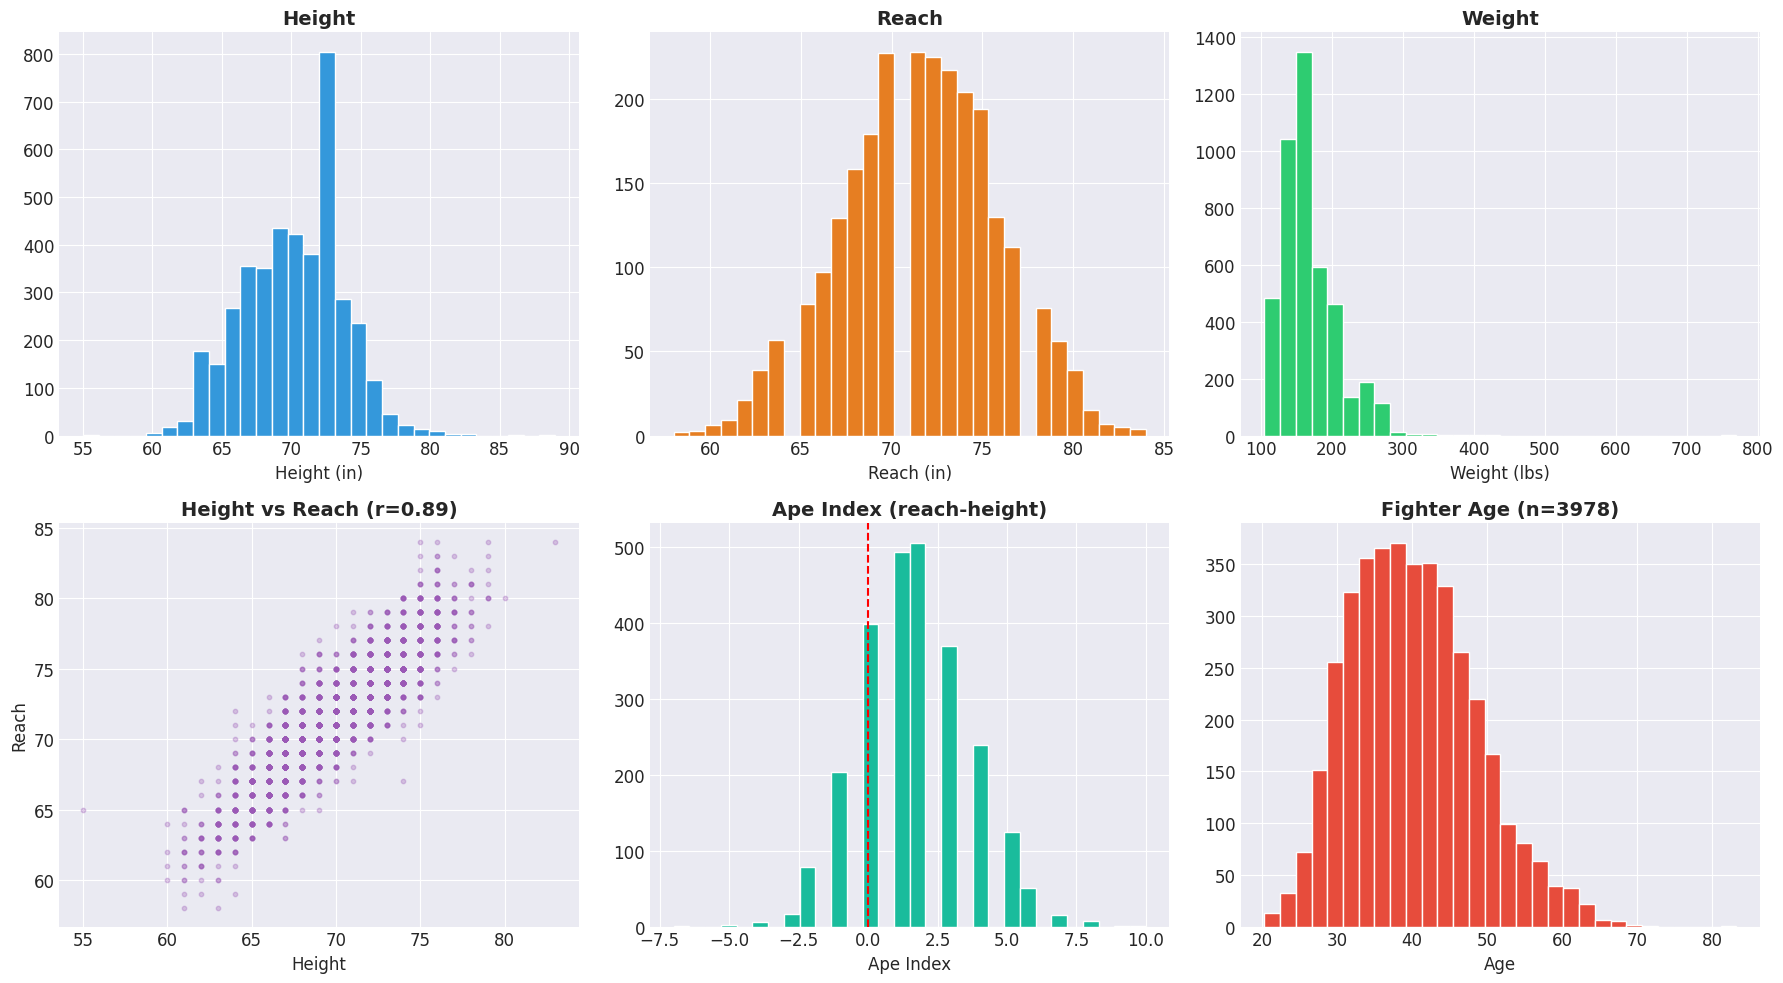

In [35]:
# notebooks/03_eda.ipynb — Cell 13: Physical Attributes

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(fighters['height_inches'].dropna(), bins=30, color='#3498db', edgecolor='white')
axes[0,0].set_xlabel('Height (in)'); axes[0,0].set_title('Height')

axes[0,1].hist(fighters['reach_inches'].dropna(), bins=30, color='#e67e22', edgecolor='white')
axes[0,1].set_xlabel('Reach (in)'); axes[0,1].set_title('Reach')

axes[0,2].hist(fighters['weight_lbs'].dropna(), bins=30, color='#2ecc71', edgecolor='white')
axes[0,2].set_xlabel('Weight (lbs)'); axes[0,2].set_title('Weight')

v = fighters.dropna(subset=['height_inches','reach_inches'])
axes[1,0].scatter(v['height_inches'], v['reach_inches'], alpha=0.3, s=10, color='#9b59b6')
cr = v['height_inches'].corr(v['reach_inches'])
axes[1,0].set_xlabel('Height'); axes[1,0].set_ylabel('Reach')
axes[1,0].set_title(f'Height vs Reach (r={cr:.2f})')

v2 = v.copy()
v2['ape'] = v2['reach_inches'] - v2['height_inches']
axes[1,1].hist(v2['ape'], bins=30, color='#1abc9c', edgecolor='white')
axes[1,1].set_xlabel('Ape Index'); axes[1,1].set_title('Ape Index (reach-height)')
axes[1,1].axvline(x=0, color='red', ls='--')

# DOB / Age distribution
dob_valid = fighters['dob_parsed'].dropna()
ages = (pd.Timestamp.now() - pd.to_datetime(dob_valid)).dt.days / 365.25
axes[1,2].hist(ages, bins=30, color='#e74c3c', edgecolor='white')
axes[1,2].set_xlabel('Age'); axes[1,2].set_title(f'Fighter Age (n={len(ages)})')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_12_physical.png', dpi=150, bbox_inches='tight')
plt.show()

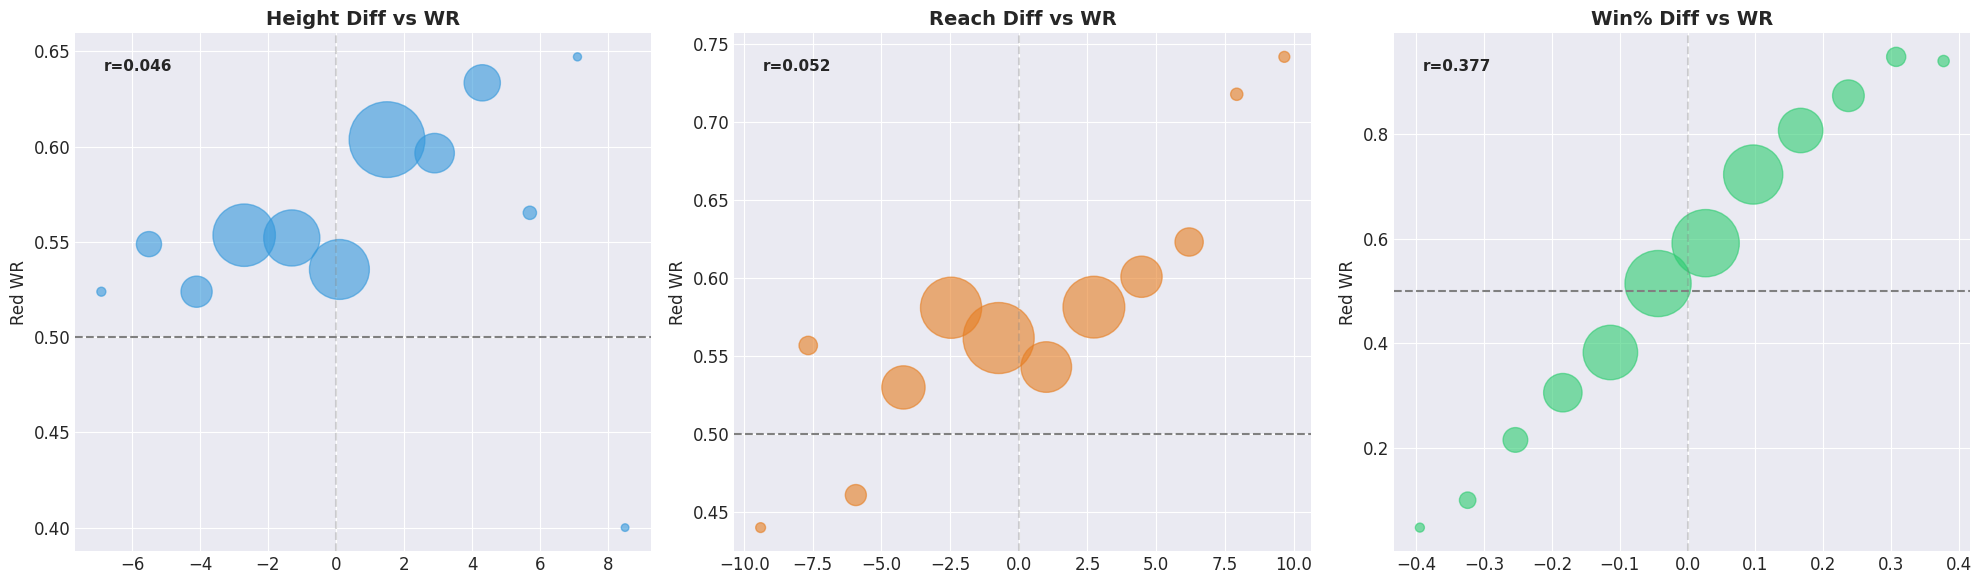

  Height diff corr with f1_win: 0.0465
  Reach diff corr with f1_win: 0.0519
  Win% diff corr with f1_win: 0.3768


In [36]:
# notebooks/03_eda.ipynb — Cell 14: Physical Diffs vs Win Rate

fp2 = fighters[['full_name','height_inches','reach_inches','win_pct']].copy()
fm2 = fights.merge(
    fp2.rename(columns={'full_name':'fighter_1','height_inches':'f1_ht',
                       'reach_inches':'f1_rc','win_pct':'f1_wp'}),
    on='fighter_1', how='left')
fm2 = fm2.merge(
    fp2.rename(columns={'full_name':'fighter_2','height_inches':'f2_ht',
                       'reach_inches':'f2_rc','win_pct':'f2_wp'}),
    on='fighter_2', how='left')
fm2['ht_diff'] = fm2['f1_ht'] - fm2['f2_ht']
fm2['rc_diff'] = fm2['f1_rc'] - fm2['f2_rc']
fm2['wp_diff'] = fm2['f1_wp'] - fm2['f2_wp']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col, clr, title in [
    (axes[0], 'ht_diff', '#3498db', 'Height Diff vs WR'),
    (axes[1], 'rc_diff', '#e67e22', 'Reach Diff vs WR'),
    (axes[2], 'wp_diff', '#2ecc71', 'Win% Diff vs WR'),
]:
    valid = fm2[col].dropna()
    if len(valid) < 50:
        ax.set_title(f'{title} (insufficient data)'); continue
    bns = pd.cut(fm2[col], bins=15)
    grp = fm2.groupby(bns, observed=True)['f1_win'].agg(['mean','count'])
    grp = grp[grp['count']>=15]
    xv = [i.mid for i in grp.index]
    ax.scatter(xv, grp['mean'], s=grp['count']*2, alpha=0.6, c=clr)
    ax.axhline(y=0.5, color='gray', ls='--')
    ax.axvline(x=0, color='gray', ls='--', alpha=0.3)
    ax.set_ylabel('Red WR'); ax.set_title(title)
    corr = fm2[col].corr(fm2['f1_win'])
    ax.text(0.05, 0.95, f'r={corr:.3f}', transform=ax.transAxes,
            fontsize=11, va='top', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_13_physical_diffs.png', dpi=150, bbox_inches='tight')
plt.show()

for col, name in [('ht_diff','Height'),('rc_diff','Reach'),('wp_diff','Win%')]:
    m = fm2[col].notna()
    if m.sum() > 0:
        print(f'  {name} diff corr with f1_win: '
              f'{fm2.loc[m,col].corr(fm2.loc[m,"f1_win"]):.4f}')

## 8. Correlations

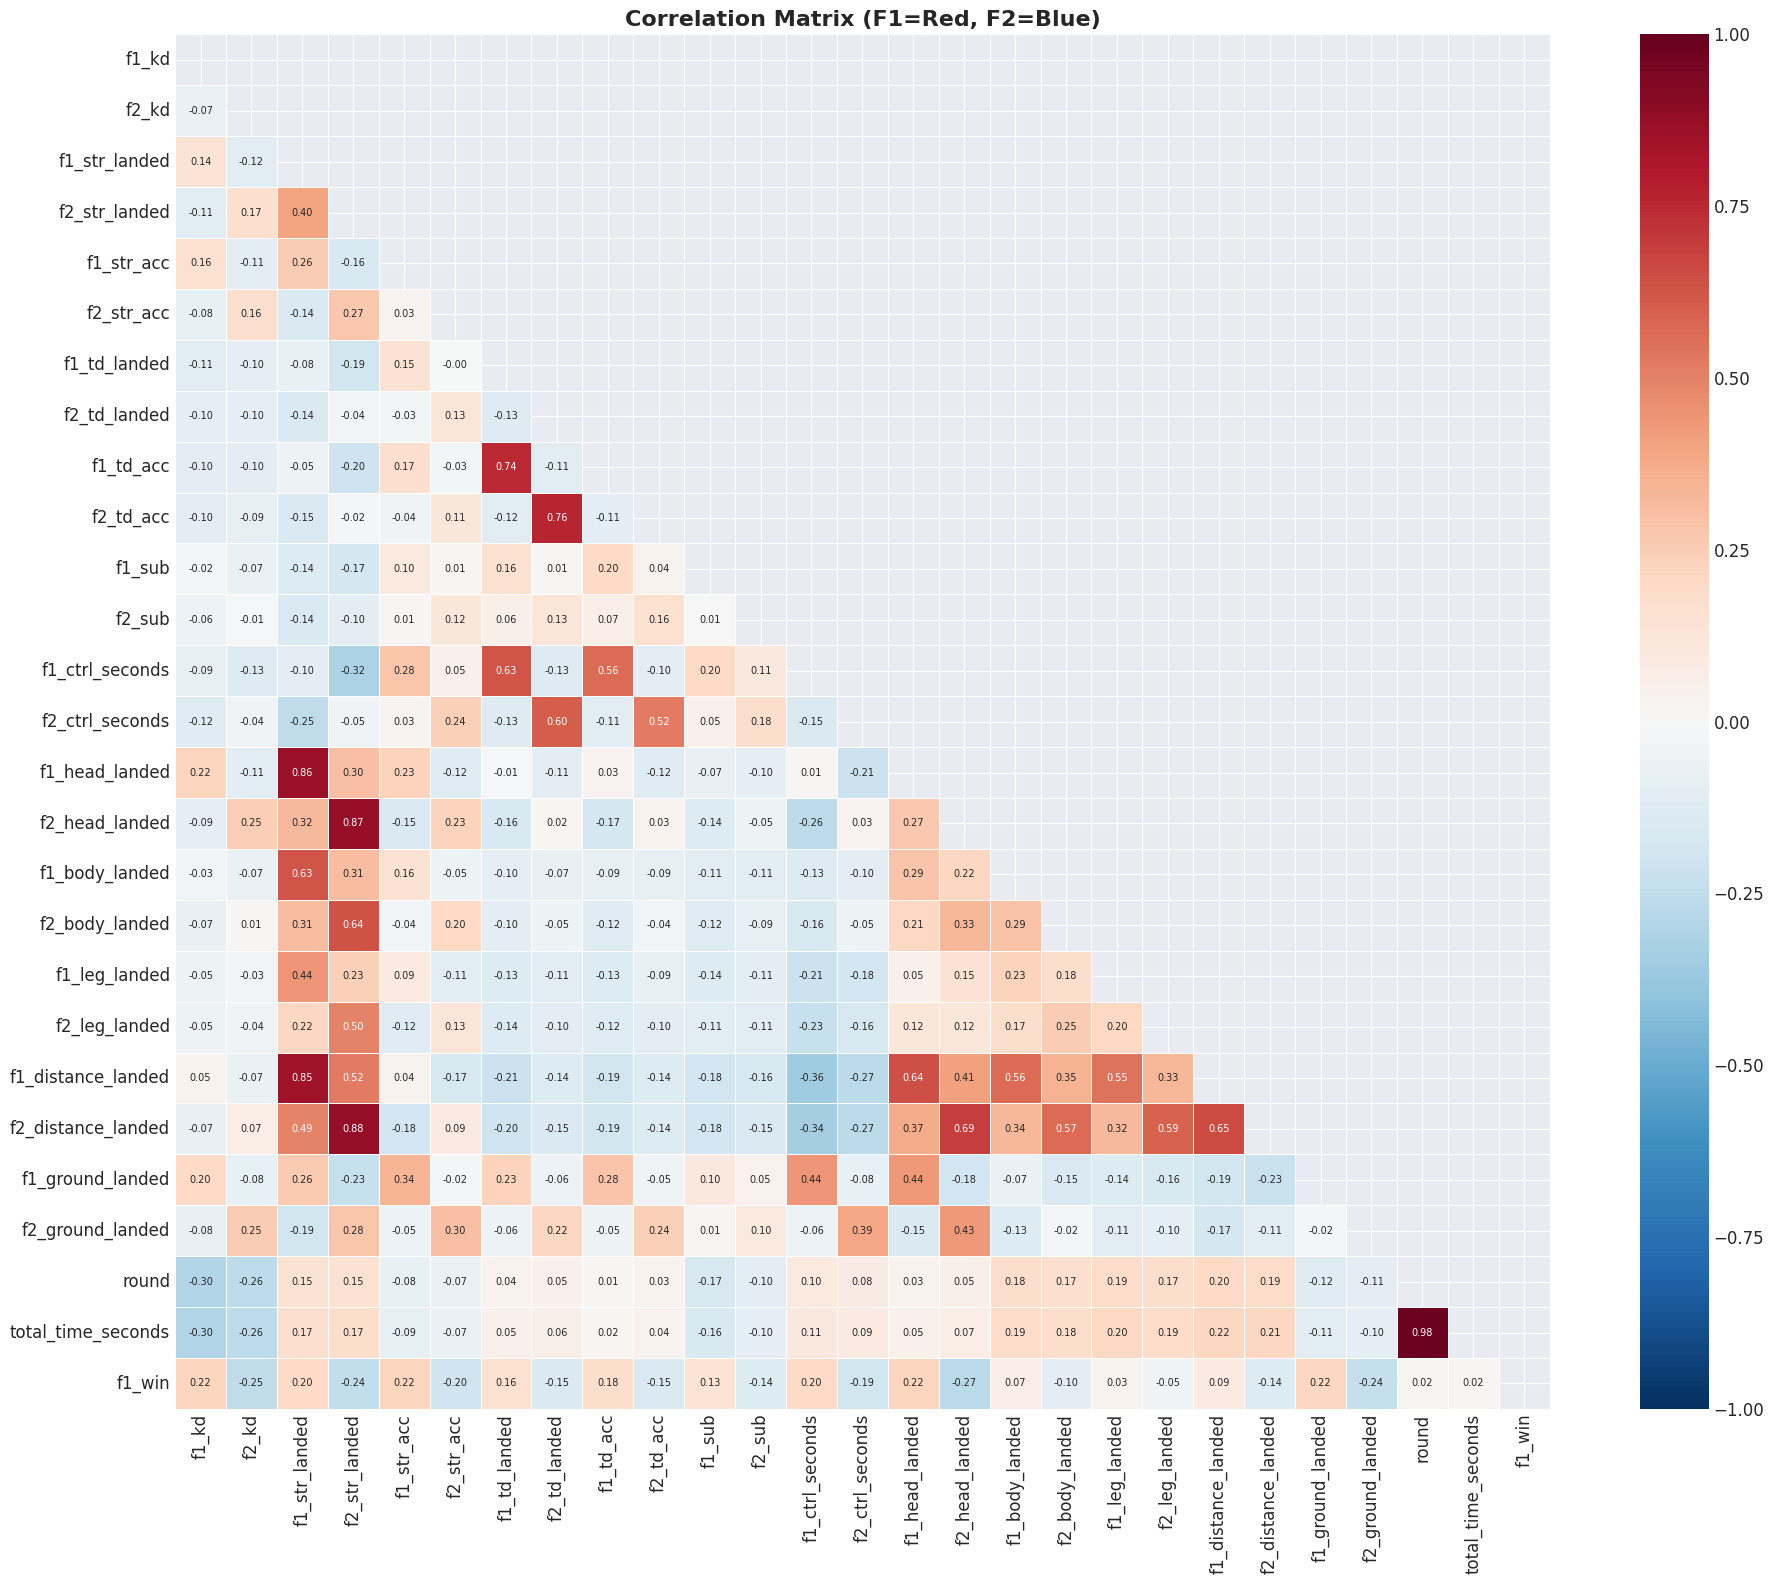

In [37]:
# notebooks/03_eda.ipynb — Cell 15: Correlation Matrix

num_cols = [
    'f1_kd','f2_kd','f1_str_landed','f2_str_landed',
    'f1_str_acc','f2_str_acc','f1_td_landed','f2_td_landed',
    'f1_td_acc','f2_td_acc','f1_sub','f2_sub',
    'f1_ctrl_seconds','f2_ctrl_seconds',
    'f1_head_landed','f2_head_landed',
    'f1_body_landed','f2_body_landed',
    'f1_leg_landed','f2_leg_landed',
    'f1_distance_landed','f2_distance_landed',
    'f1_ground_landed','f2_ground_landed',
    'round','total_time_seconds','f1_win'
]
cols = [c for c in num_cols if c in fights.columns]
cm = fights[cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            annot_kws={'size':7}, linewidths=0.5)
ax.set_title('Correlation Matrix (F1=Red, F2=Blue)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_14_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

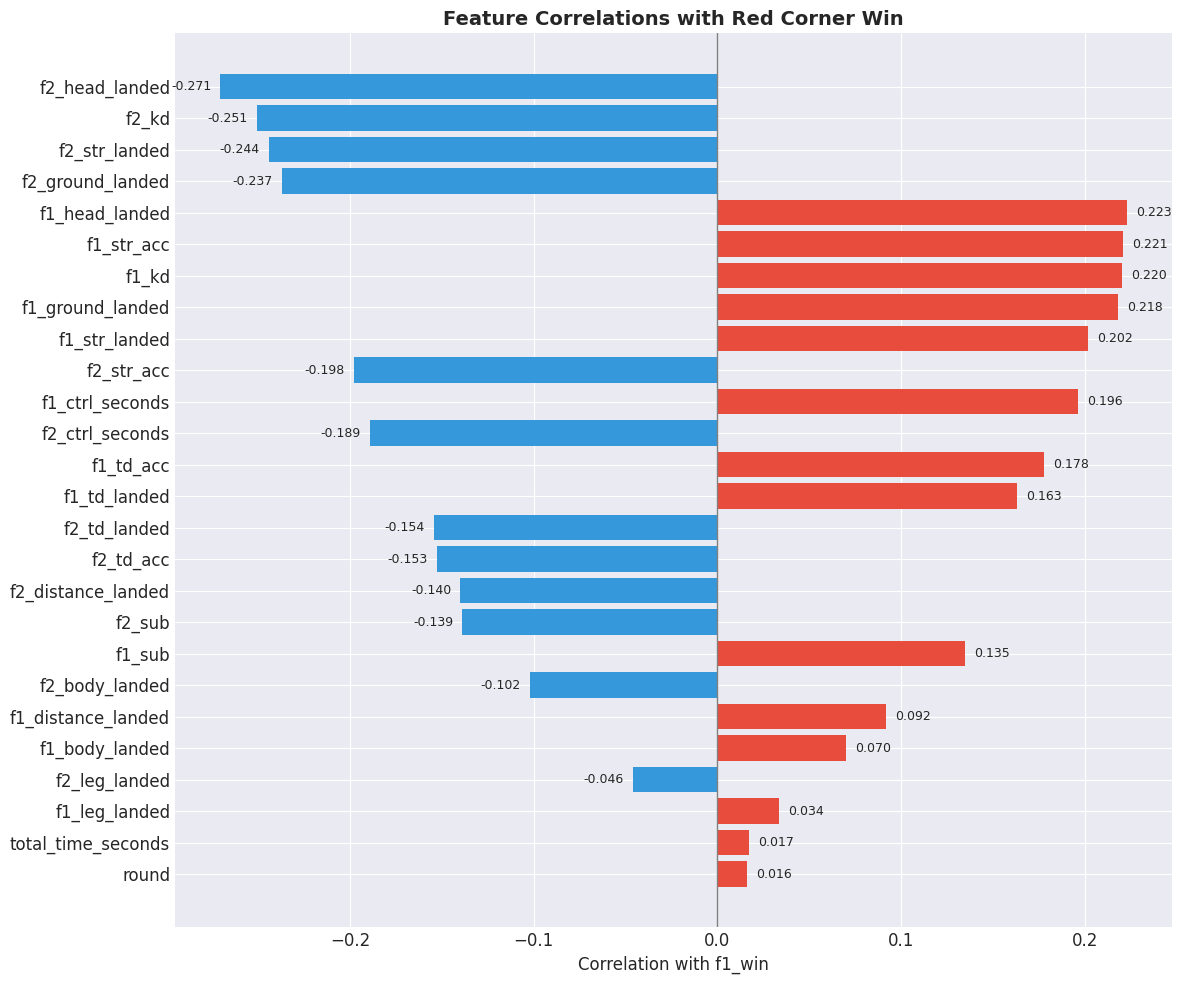

All correlations with f1_win:
  - f2_head_landed                 -0.2707
  - f2_kd                          -0.2508
  - f2_str_landed                  -0.2444
  - f2_ground_landed               -0.2371
  + f1_head_landed                 +0.2229
  + f1_str_acc                     +0.2209
  + f1_kd                          +0.2202
  + f1_ground_landed               +0.2182
  + f1_str_landed                  +0.2015
  - f2_str_acc                     -0.1978
  + f1_ctrl_seconds                +0.1962
  - f2_ctrl_seconds                -0.1891
  + f1_td_acc                      +0.1781
  + f1_td_landed                   +0.1633
  - f2_td_landed                   -0.1543
  - f2_td_acc                      -0.1526
  - f2_distance_landed             -0.1399
  - f2_sub                         -0.1390
  + f1_sub                         +0.1347
  - f2_body_landed                 -0.1021
  + f1_distance_landed             +0.0915
  + f1_body_landed                 +0.0698
  - f2_leg_landed       

In [38]:
# notebooks/03_eda.ipynb — Cell 16: Top Correlations Bar Chart

wc_corr = cm['f1_win'].drop('f1_win').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(len(wc_corr)), wc_corr.values,
        color=['#e74c3c' if c>0 else '#3498db' for c in wc_corr.values])
ax.set_yticks(range(len(wc_corr))); ax.set_yticklabels(wc_corr.index)
ax.set_xlabel('Correlation with f1_win')
ax.set_title('Feature Correlations with Red Corner Win')
ax.axvline(x=0, color='gray', lw=1); ax.invert_yaxis()
for i, (f, c) in enumerate(wc_corr.items()):
    ha = 'left' if c>0 else 'right'
    ax.text(c+(0.005 if c>0 else -0.005), i, f'{c:.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_15_top_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('All correlations with f1_win:')
for f, c in wc_corr.items():
    print(f'  {"+" if c>0 else "-"} {f:30s} {c:+.4f}')

## 9. Stance Matchups

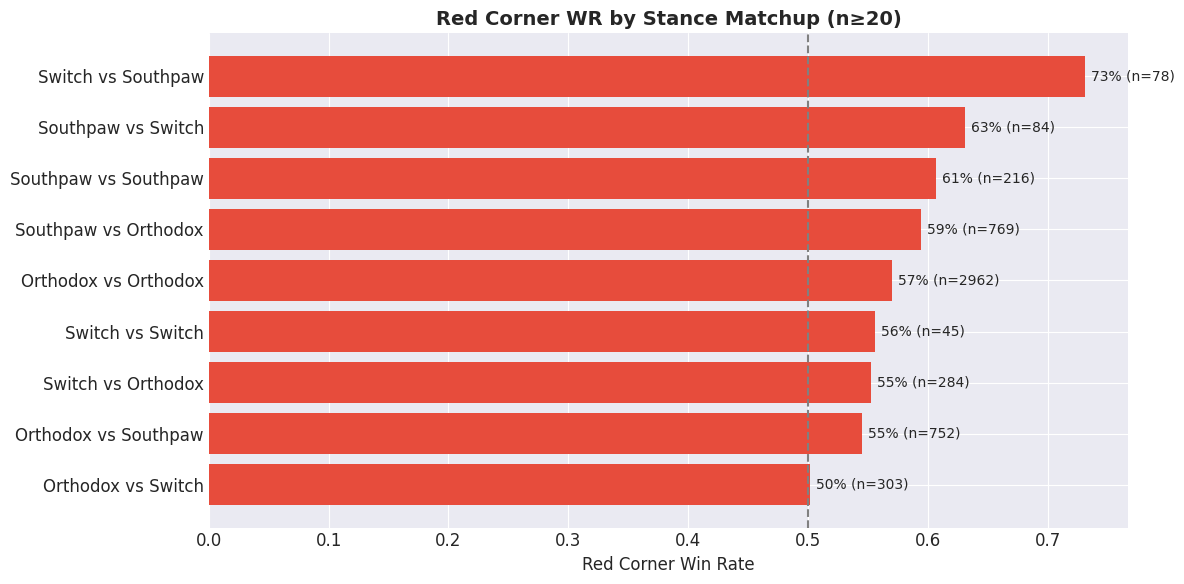

Fights with stance data: 5493/5485
                          mean  count
matchup                              
Switch vs Southpaw    0.730769     78
Southpaw vs Switch    0.630952     84
Southpaw vs Southpaw  0.606481    216
Southpaw vs Orthodox  0.594278    769
Orthodox vs Orthodox  0.569885   2962
Switch vs Switch      0.555556     45
Switch vs Orthodox    0.552817    284
Orthodox vs Southpaw  0.545213    752
Orthodox vs Switch    0.501650    303


In [39]:
# notebooks/03_eda.ipynb — Cell 17: Stance Matchups

fs = fighters[['full_name','stance']].copy()
fs = fs[fs['stance'].isin(['Orthodox','Southpaw','Switch'])]

sm = fights.merge(
    fs.rename(columns={'full_name':'fighter_1','stance':'f1_stance'}),
    on='fighter_1', how='left')
sm = sm.merge(
    fs.rename(columns={'full_name':'fighter_2','stance':'f2_stance'}),
    on='fighter_2', how='left')
sm = sm.dropna(subset=['f1_stance','f2_stance']).copy()
sm['matchup'] = sm['f1_stance'] + ' vs ' + sm['f2_stance']

ms = sm.groupby('matchup')['f1_win'].agg(['mean','count'])
ms = ms[ms['count']>=20].sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
mcolors = ['#e74c3c' if m>0.5 else '#3498db' for m in ms['mean']]
ax.barh(range(len(ms)), ms['mean'], color=mcolors)
ax.set_yticks(range(len(ms))); ax.set_yticklabels(ms.index)
ax.axvline(x=0.5, color='gray', ls='--')
ax.set_xlabel('Red Corner Win Rate')
ax.set_title('Red Corner WR by Stance Matchup (n≥20)')
ax.invert_yaxis()
for i, (_, r) in enumerate(ms.iterrows()):
    ax.text(r['mean']+0.005, i,
            f'{r["mean"]:.0%} (n={int(r["count"])})', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_16_stances.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fights with stance data: {len(sm)}/{len(fights)}')
print(ms.to_string())

## 10. Key Insights & Next Steps

In [40]:
# notebooks/03_eda.ipynb — Cell 18: Key Insights

print('=' * 70)
print('EDA KEY INSIGHTS')
print('=' * 70)

print(f'\n1. DATASET: {len(fights)} decided fights, 2015-2026')
print(f'   Baseline (always pick red): {fights["f1_win"].mean():.1%}')

print(f'\n2. FINISH TYPES:')
for ft in ['DEC','KO/TKO','SUB','OTHER']:
    n = (fights['finish_type']==ft).sum()
    if n > 0:
        print(f'   {ft:8s} {n/len(fights):.1%} ({n})')

print(f'\n3. IN-FIGHT CORRELATIONS WITH f1_win:')
top_c = cm['f1_win'].drop('f1_win').sort_values(key=abs, ascending=False)
for f, c in top_c.head(8).items():
    print(f'   {f:30s} {c:+.3f}')

print(f'\n4. CAREER STAT DIFF CORRELATIONS (pre-fight usable):')
for stat, title in diff_stats:
    col = f'diff_{stat}'
    valid = fm[[col,'f1_win']].dropna()
    if len(valid) > 0:
        corr = valid[col].corr(valid['f1_win'])
        print(f'   {title:30s} {corr:+.4f}')

print(f'\n5. STRIKE LOCATION (winner vs loser):')
for loc in ['head','body','leg']:
    wm = fights[f'winner_{loc}_landed'].mean()
    lm = fights[f'loser_{loc}_landed'].mean()
    print(f'   {loc:6s}  W={wm:.2f}  L={lm:.2f}  diff={wm-lm:+.2f}')

print(f'\n6. STRIKE POSITION (winner vs loser per fight):')
for pos in ['distance','clinch','ground']:
    wm = fights[f'winner_{pos}_landed'].mean()
    lm = fights[f'loser_{pos}_landed'].mean()
    print(f'   {pos:10s}  W={wm:.2f}  L={lm:.2f}  diff={wm-lm:+.2f}')

print(f'\n7. PHYSICAL DIFFS:')
for col, name in [('ht_diff','Height'),('rc_diff','Reach'),('wp_diff','Win%')]:
    if col in fm2.columns:
        m = fm2[col].notna()
        if m.sum() > 0:
            corr = fm2.loc[m,col].corr(fm2.loc[m,'f1_win'])
            print(f'   {name:10s} diff corr: {corr:+.4f}')

print(f'\n8. FIGHTER CAREER RATE STATS:')
for col, label in zip(
    ['slpm','sapm','str_acc_career','str_def_career',
     'td_avg','td_acc_career','td_def_career','sub_avg'],
    ['SLpM','SApM','Str Acc','Str Def',
     'TD Avg','TD Acc','TD Def','Sub Avg']):
    d = fighters[col].dropna()
    print(f'   {label:10s} n={len(d):>5d}  mean={d.mean():.3f}  std={d.std():.3f}')

print(f'\n9. DATA AVAILABLE FOR FEATURE ENGINEERING:')
print(f'   Fight stats: {len(fights.columns)} columns, 0 nulls in core stats')
print(f'   Fighter career: SLpM, SApM, Str Acc/Def, TD Avg/Acc/Def, Sub Avg')
print(f'   Strike location: head/body/leg landed + attempted')
print(f'   Strike position: distance/clinch/ground landed + attempted')
print(f'   Physical: height, reach, weight, stance, DOB/age')
print(f'   Context: weight class, method, round, time')

print(f'\n10. FEATURE ENGINEERING PRIORITIES:')
print(f'   - Current in-fight stats must become PRE-FIGHT rolling averages')
print(f'   - Career rate stats (SLpM etc.) are already pre-fight usable')
print(f'   - Compute differentials: F1_stat - F2_stat for all features')
print(f'   - Rolling windows: last 3 and 5 fights')
print(f'   - Win streak, days since last fight, activity rate')
print(f'   - Opponent quality (avg opp win rate)')
print(f'   - CRITICAL: only use data from BEFORE each fight (anti-leakage)')

print(f'\n   BASELINE TO BEAT: {fights["f1_win"].mean():.1%}')
print('=' * 70)

EDA KEY INSIGHTS

1. DATASET: 5485 decided fights, 2015-2026
   Baseline (always pick red): 57.1%

2. FINISH TYPES:
   DEC      49.9% (2737)
   KO/TKO   32.1% (1760)
   SUB      17.8% (975)
   OTHER    0.2% (13)

3. IN-FIGHT CORRELATIONS WITH f1_win:
   f2_head_landed                 -0.271
   f2_kd                          -0.251
   f2_str_landed                  -0.244
   f2_ground_landed               -0.237
   f1_head_landed                 +0.223
   f1_str_acc                     +0.221
   f1_kd                          +0.220
   f1_ground_landed               +0.218

4. CAREER STAT DIFF CORRELATIONS (pre-fight usable):
   SLpM Diff                      +0.1894
   SApM Diff (lower=better)       -0.1795
   Str Acc Diff                   +0.2381
   Str Def Diff                   +0.1614
   TD Avg Diff                    +0.1121
   Win% Diff                      +0.3768

5. STRIKE LOCATION (winner vs loser):
   head    W=11.27  L=7.16  diff=+4.11
   body    W=3.76  L=3.10  diff=+0.65